In [ ]:
!pip install shap
!pip install boruta

In [ ]:
import pandas as pd
import numpy as np
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import xgboost as xgbimport
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from boruta import BorutaPy



# Load the data
df = pd.read_csv(
    'large_fires_data_v2_ndfb_kd_co.csv',
    names= [
        'Point ID',
        'Latitude',
        'Longitude',
        'ndfb_kd_co',
        'Aspect',
        'Climatic water deficit',
        'Elevation',
        'Humidity',
        'LULC',
        'NDVI',
        'Evaptranspiration',
        'Precipitation',
        'Slope',
        'Soil moisture',
        'Shortwave radiation flux',
        'Maximum Temperature',
        'Wind speed',
        'Distance from forest',
        'Human foot',
        'Tree species',
        'pdsi'
    ],
    header= 0
)

In [ ]:
df.head()

,Point ID,Latitude,Longitude,ndfb_kd_co,Aspect,Climatic water deficit,Elevation,Humidity,LULC,NDVI,...,Precipitation,Slope,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,Distance from forest,Human foot,Tree species,pdsi
0,118462,60.383883,-100.961333,0.003040,108,25.791901,343.622009,0.003105,5,0.185952,...,33.974201,0,38.638302,122.428001,-2.81874,5.04358,0.00000,0,18,3.842920
1,188536,68.383883,-97.544667,0.000000,30,-9999.000000,29.983200,0.002183,8,0.079882,...,-9999.000000,0,-9999.000000,-9999.000000,-9999.00000,-9999.00000,306.02301,0,0,-9999.000000
2,142254,63.383883,-94.961333,0.000000,113,35.641201,142.042007,0.002544,3,0.118337,...,25.044300,0,39.882900,120.940002,-5.93237,5.63601,45.00000,0,0,-0.417361
3,170110,66.383883,-123.044667,0.000598,-1,25.696800,156.000000,0.003055,11,-0.051117,...,22.537500,0,18.849199,104.688003,-1.79748,3.65383,14.14210,-9999,0,-0.851500
4,5182,46.133883,-73.544667,0.000017,25,16.150000,94.138496,0.005531,2,0.429686,...,96.328300,0,49.552502,146.054001,10.93730,2.69233,0.00000,32,0,1.050420


In [ ]:
# Replace -9999 with NaN
df.replace(-9999, np.nan, inplace=True)

# Verify if replacement was successful by checking for null values
df.isnull().sum()

,0
Point ID,0
Latitude,0
Longitude,0
ndfb_kd_co,0
Aspect,27
Climatic water deficit,78
Elevation,171
Humidity,98
LULC,103
NDVI,115


In [ ]:
# Drop rows with NaN values
df.dropna(inplace=True)

In [ ]:
replace_values_LULC = {
    1: 'Urban areas',
    2: 'Crop land',
    3: 'Grass land',
    4: 'Tree covered',
    5: 'Shrub covered',
    6: 'Herbaceous',
    8: 'Sparse vegetation',
    9: 'Bare soil',
    10: 'Snow',
    11: 'Water bodies',
}

df['LULC'] = df['LULC'].replace(replace_values_LULC)

In [ ]:
df.head(10)

,Point ID,Latitude,Longitude,ndfb_kd_co,Aspect,Climatic water deficit,Elevation,Humidity,LULC,NDVI,...,Precipitation,Slope,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,Distance from forest,Human foot,Tree species,pdsi
0,118462,60.383883,-100.961333,0.003040,108.0,25.791901,343.622009,0.003105,Shrub covered,0.185952,...,33.974201,0.0,38.638302,122.428001,-2.81874,5.04358,0.000000,0.0,18.0,3.842920
2,142254,63.383883,-94.961333,0.000000,113.0,35.641201,142.042007,0.002544,Grass land,0.118337,...,25.044300,0.0,39.882900,120.940002,-5.93237,5.63601,45.000000,0.0,0.0,-0.417361
4,5182,46.133883,-73.544667,0.000017,25.0,16.150000,94.138496,0.005531,Crop land,0.429686,...,96.328300,0.0,49.552502,146.054001,10.93730,2.69233,0.000000,32.0,0.0,1.050420
5,5180,46.133883,-73.711333,0.000000,62.0,14.517400,213.761993,0.005358,Tree covered,0.509989,...,99.220001,1.0,53.683300,145.434998,10.80500,2.62192,0.000000,15.0,6.0,1.075170
6,23536,49.883883,-110.961333,0.000000,102.0,85.902199,766.164002,0.004427,Crop land,0.306533,...,25.574200,0.0,8.550000,159.216995,12.03230,4.51617,49.497501,17.0,0.0,-0.115882
7,171330,66.467217,-88.378000,0.000000,74.0,34.307098,298.561005,0.002100,Sparse vegetation,0.064672,...,25.674900,0.0,11.649000,112.188003,-8.41979,4.58282,386.942993,0.0,0.0,-0.419509
8,171040,66.467217,-112.628000,0.000000,205.0,37.411499,481.976990,0.002597,Grass land,0.126665,...,20.446300,0.0,25.186300,105.348999,-5.18341,4.58974,63.245602,0.0,0.0,0.649869
9,133520,62.300550,-101.711333,0.002948,-1.0,16.660000,266.000000,0.002877,Water bodies,0.000924,...,27.469000,0.0,38.008800,118.398003,-4.02748,5.48379,18.027800,0.0,0.0,0.135204
11,197830,69.717217,-95.294667,0.000000,236.0,28.190901,16.423500,0.002033,Sparse vegetation,0.037350,...,13.080000,0.0,5.873330,104.623001,-9.58655,4.75425,411.096008,0.0,0.0,-2.166500
12,165028,65.800550,-88.628000,0.000000,217.0,36.887501,180.914002,0.002130,Sparse vegetation,0.084306,...,26.125700,1.0,14.422900,114.267998,-7.52132,5.24746,345.398010,0.0,0.0,0.046837


In [ ]:
# Convert necessary columns to categorical
df = df.astype(
    {
        'LULC': 'category'
    }
)

In [ ]:
# # Replace -9999 with NaN
# df.replace(-9999, np.nan, inplace= True)

# # Fill NaN values using forward and Backward fill
# df.fillna(method='ffill', inplace= True)
# df.fillna(method= 'bfill', inplace= True)

In [ ]:
df

,Point ID,Latitude,Longitude,ndfb_kd_co,Aspect,Climatic water deficit,Elevation,Humidity,LULC,NDVI,...,Precipitation,Slope,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,Distance from forest,Human foot,Tree species,pdsi
0,118462,60.383883,-100.961333,0.003040,108.0,25.791901,343.622009,0.003105,Shrub covered,0.185952,...,33.974201,0.0,38.638302,122.428001,-2.818740,5.04358,0.000000,0.0,18.0,3.842920
2,142254,63.383883,-94.961333,0.000000,113.0,35.641201,142.042007,0.002544,Grass land,0.118337,...,25.044300,0.0,39.882900,120.940002,-5.932370,5.63601,45.000000,0.0,0.0,-0.417361
4,5182,46.133883,-73.544667,0.000017,25.0,16.150000,94.138496,0.005531,Crop land,0.429686,...,96.328300,0.0,49.552502,146.054001,10.937300,2.69233,0.000000,32.0,0.0,1.050420
5,5180,46.133883,-73.711333,0.000000,62.0,14.517400,213.761993,0.005358,Tree covered,0.509989,...,99.220001,1.0,53.683300,145.434998,10.805000,2.62192,0.000000,15.0,6.0,1.075170
6,23536,49.883883,-110.961333,0.000000,102.0,85.902199,766.164002,0.004427,Crop land,0.306533,...,25.574200,0.0,8.550000,159.216995,12.032300,4.51617,49.497501,17.0,0.0,-0.115882
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,42164,51.800550,-119.294667,0.066987,298.0,40.247398,1234.609985,0.004255,Tree covered,0.364348,...,82.198196,17.0,38.228600,137.061996,10.527200,1.63274,0.000000,12.0,30.0,-0.320638
9996,83453,55.967217,-102.628000,0.094061,10.0,24.782600,390.493988,0.003904,Shrub covered,0.360019,...,43.674999,0.0,36.657501,135.151993,4.036580,3.20392,0.000000,0.0,29.0,-0.532250
9997,142023,63.383883,-114.211333,0.066603,45.0,45.147499,304.996002,0.003006,Shrub covered,0.226289,...,23.678700,0.0,20.494400,115.484001,-0.881827,3.87582,0.000000,0.0,10.0,-0.742617
9998,21169,49.633883,-121.544667,0.151077,21.0,36.743301,1519.750000,0.004994,Tree covered,0.370431,...,89.547996,10.0,120.483002,135.684006,10.706200,2.26293,0.000000,0.0,0.0,-0.813372


In [ ]:
# Define features and target, X and y
X = df.drop(columns= ['ndfb_kd_co'])
y = df['ndfb_kd_co']

# Split data into training, validation and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [ ]:
# Combine features and target back for each dataset
train_data = pd.concat([X_train[['Latitude', 'Longitude']], y_train], axis=1)
val_data = pd.concat([X_val[['Latitude', 'Longitude']], y_val], axis=1)
test_data = pd.concat([X_test[['Latitude', 'Longitude']], y_test], axis=1)

# Save to CSV files
train_data.to_csv('training_data.csv', index=False)
val_data.to_csv('validation_data.csv', index=False)
test_data.to_csv('testing_data.csv', index=False)

In [ ]:
# Define the columns to separate out
index_columns = [

                 'Point ID',
                 'Latitude',
                 'Longitude',
                 'Distance from forest',
                 'Human foot',
                 'Tree species',
                 'pdsi'
]

# Separate index columns for train, validation, and test sets
train_indices = X_train[index_columns]
val_indices = X_val[index_columns]
test_indices = X_test[index_columns]

# Drop these columns from the features
X_train = X_train.drop(columns=index_columns)
X_val = X_val.drop(columns=index_columns)
X_test = X_test.drop(columns=index_columns)


In [ ]:
df.columns

Index(['Point ID', 'Latitude', 'Longitude', 'ndfb_kd_co', 'Aspect',
       'Climatic water deficit', 'Elevation', 'Humidity', 'LULC', 'NDVI',
       'Evaptranspiration', 'Precipitation', 'Slope', 'Soil moisture',
       'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed',
       'Distance from forest', 'Human foot', 'Tree species', 'pdsi'],
      dtype='object')

In [ ]:
# Define categorical and numerical columns
categorical_columns = ['LULC']
numerical_columns = ['Climatic water deficit', 'Elevation', 'Humidity','NDVI',
       'Evaptranspiration', 'Precipitation', 'Slope', 'Soil moisture',
       'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed',]

# Initialize the OneHotEncoder and StandardScaler
encoder = OneHotEncoder(sparse_output=False)
scaler = StandardScaler()

# Fit and transform encoders/scalers on training data
X_train_encoded = pd.DataFrame(encoder.fit_transform(X_train[categorical_columns]),
                               columns=encoder.get_feature_names_out(categorical_columns))
X_val_encoded = pd.DataFrame(encoder.transform(X_val[categorical_columns]),
                             columns=encoder.get_feature_names_out(categorical_columns))
X_test_encoded = pd.DataFrame(encoder.transform(X_test[categorical_columns]),
                              columns=encoder.get_feature_names_out(categorical_columns))

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train[numerical_columns]), columns=numerical_columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val[numerical_columns]), columns=numerical_columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test[numerical_columns]), columns=numerical_columns)

# Concatenate encoded categorical and scaled numerical features
X_train_final = pd.concat([X_train_scaled.reset_index(drop=True), X_train_encoded.reset_index(drop=True)], axis=1)
X_val_final = pd.concat([X_val_scaled.reset_index(drop=True), X_val_encoded.reset_index(drop=True)], axis=1)
X_test_final = pd.concat([X_test_scaled.reset_index(drop=True), X_test_encoded.reset_index(drop=True)], axis=1)

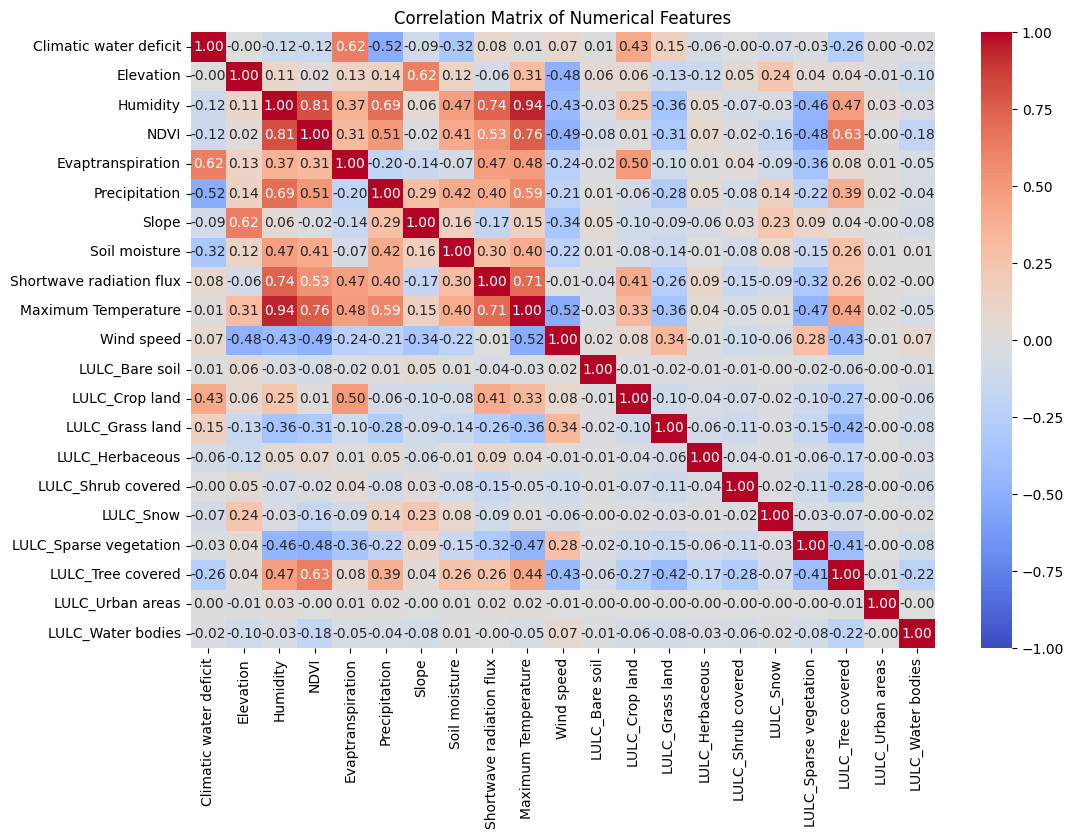

In [ ]:
# Calculate correlation matrix for numerical features
correlation_matrix = X_train_final.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Numerical Features")
plt.show()


In [ ]:
print(df[['Maximum Temperature', 'Humidity', 'ndfb_kd_co']].corr())

                     Maximum Temperature  Humidity  ndfb_kd_co
Maximum Temperature             1.000000  0.940449    0.213388
Humidity                        0.940449  1.000000    0.172080
ndfb_kd_co                      0.213388  0.172080    1.000000


In [ ]:
# Initialize the RandomForestRegressor
rf = RandomForestRegressor(n_jobs=-1, max_depth=20, random_state=42)

# Fit the RandomForest model to get the feature importances
rf.fit(X_train_final, y_train)

# Initialize Boruta with the RandomForest model
boruta = BorutaPy(estimator=rf, n_estimators=20, max_iter=20, random_state=42, verbose=1)

# Fit Boruta on the preprocessed training data
boruta.fit(X_train_final.values, y_train.values)

# Create a DataFrame for the Boruta results
boruta_feature_stats = pd.DataFrame({
    'Variables': X_train_final.columns,
    'BorutaDecision': ['Confirmed' if decision else 'Rejected' for decision in boruta.support_]
})

# Initialize the DecisionTreeRegressor (CART)
cart_model = DecisionTreeRegressor(random_state=42)

# Fit the CART model to the training data
cart_model.fit(X_train_final, y_train)

# Extract feature importances
feature_importances = cart_model.feature_importances_

# Create a DataFrame for the CART results
cart_feature_stats = pd.DataFrame({
    'Variables': X_train_final.columns,
    'RelativeImportance': feature_importances
})

# Combine Boruta and CART results
combined_feature_stats = boruta_feature_stats.merge(cart_feature_stats, on='Variables')

# Save the combined feature stats (both confirmed and rejected) to a CSV file
combined_feature_stats.to_csv('final_feature_stats_with_rejected.csv', index=False)

# Features removed by Boruta
boruta_removed_features = combined_feature_stats[combined_feature_stats['BorutaDecision'] == 'Rejected']['Variables']

# Features with very low importance in CART (threshold < 0.0005)
cart_removed_features = combined_feature_stats[combined_feature_stats['RelativeImportance'] < 0.0005]['Variables']

# Combine the removed features from both methods
removed_features = pd.concat([boruta_removed_features, cart_removed_features]).unique()

# Print removed features
print("Features removed by Boruta or CART:", removed_features)

# Display the final feature stats for those that are kept
final_feature_stats = combined_feature_stats[~combined_feature_stats['Variables'].isin(removed_features)]
print(final_feature_stats)

# Save the final confirmed features to a CSV file for documentation
final_feature_stats.to_csv('final_confirmed_features.csv', index=False)

# Drop the removed features from the datasets automatically
X_train_selected = X_train_final.drop(columns=removed_features, errors='ignore')
X_val_selected = X_val_final.drop(columns=removed_features, errors='ignore')
X_test_selected = X_test_final.drop(columns=removed_features, errors='ignore')

# Save the selected features datasets for reference
X_train_selected.to_csv('X_train_selected.csv', index=False)
X_val_selected.to_csv('X_val_selected.csv', index=False)
X_test_selected.to_csv('X_test_selected.csv', index=False)

# Display summary
print(f"Final selected features saved to: 'X_train_selected.csv', 'X_val_selected.csv', and 'X_test_selected.csv'")
print("Full feature stats (with rejected) saved to 'final_feature_stats_with_rejected.csv'")


Iteration: 1 / 20
Iteration: 2 / 20
Iteration: 3 / 20
Iteration: 4 / 20
Iteration: 5 / 20
Iteration: 6 / 20
Iteration: 7 / 20
Iteration: 8 / 20


BorutaPy finished running.

Iteration: 	9 / 20
Confirmed: 	11
Tentative: 	0
Rejected: 	10
Features removed by Boruta or CART: ['Slope' 'LULC_Bare soil' 'LULC_Grass land' 'LULC_Herbaceous'
 'LULC_Shrub covered' 'LULC_Snow' 'LULC_Sparse vegetation'
 'LULC_Tree covered' 'LULC_Urban areas' 'LULC_Water bodies']
                   Variables BorutaDecision  RelativeImportance
0     Climatic water deficit      Confirmed            0.125209
1                  Elevation      Confirmed            0.100461
2                   Humidity      Confirmed            0.050542
3                       NDVI      Confirmed            0.022444
4          Evaptranspiration      Confirmed            0.075391
5              Precipitation      Confirmed            0.071349
7              Soil moisture      Confirmed            0.043403
8   Shortwave radiation flux      

In [ ]:
# # Load the CSV file
# file_path = "/content/final_feature_stats_with_rejected.csv"  # Update with your actual file path
# df1 = pd.read_csv(file_path)

# # Sort by 'RelativeImportance' in descending order
# df_sorted = df1.sort_values(by="RelativeImportance", ascending=False)  # Corrected 'ascending'

# # Save the sorted file
# df_sorted.to_csv("final_feature_stats_sorted.csv", index=False)

# # Display sorted DataFrame
# print(df_sorted)

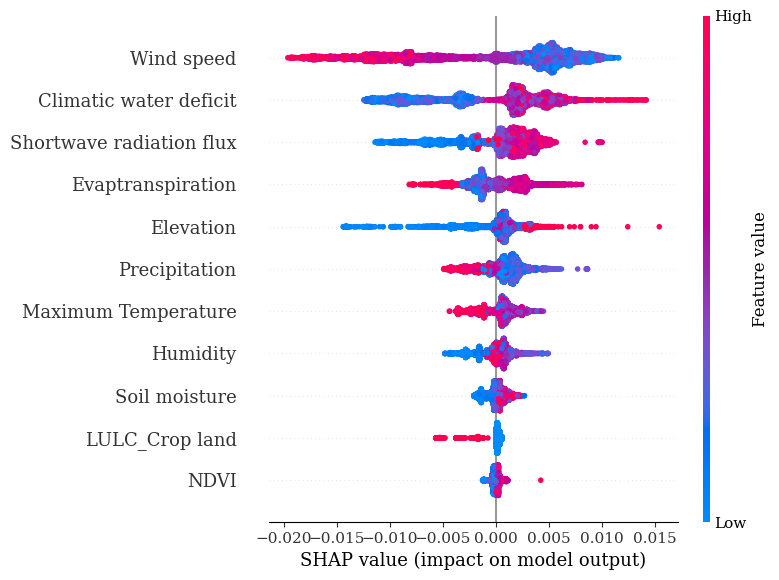

In [ ]:
import shap
import xgboost as xgb
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

# Convert datasets to XGBoost DMatrix for better performance (optional)
dtrain = xgb.DMatrix(X_train_selected, label=y_train)
dval = xgb.DMatrix(X_val_final, label=y_val)

# Train the XGBoost model
xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.01, random_state=42)
xgb_model.fit(X_train_selected, y_train)

# Compute SHAP values
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_train_selected)

# SHAP summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train_selected, feature_names=X_train_selected.columns)


SHAP summary plot saved as 'shap_summary.svg'.


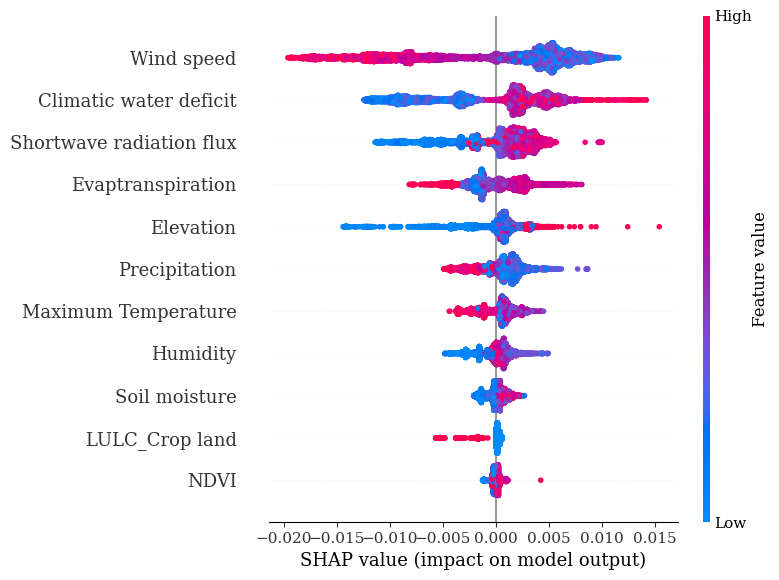

In [ ]:
# SHAP summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train_selected, feature_names=X_train_selected.columns, show=False)

# Save the figure as SVG
plt.savefig("shap_summary.svg", format="svg", bbox_inches="tight")

print("SHAP summary plot saved as 'shap_summary.svg'.")

In [ ]:
!pip install shapiq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.8/240.8 kB 6.1 MB/s eta 0:00:00


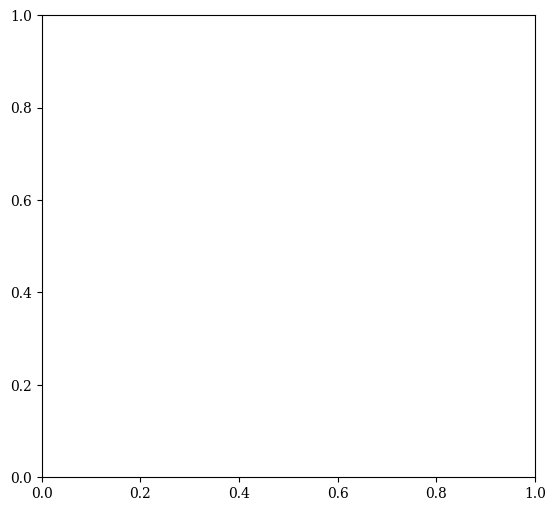

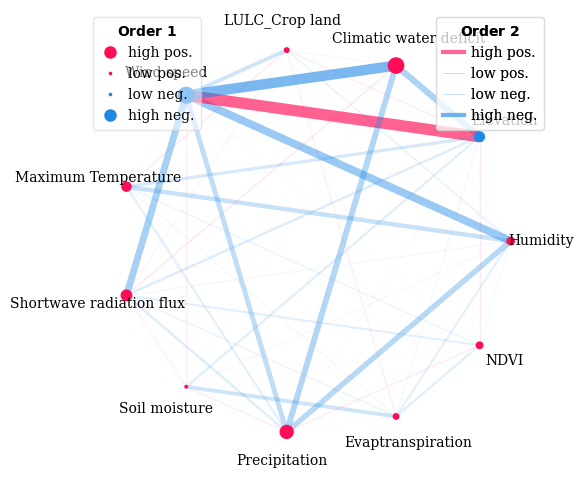

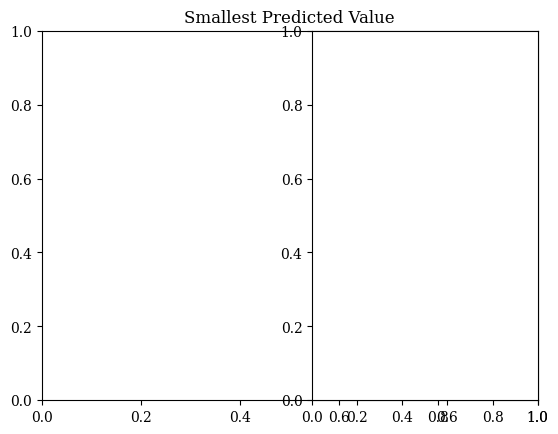

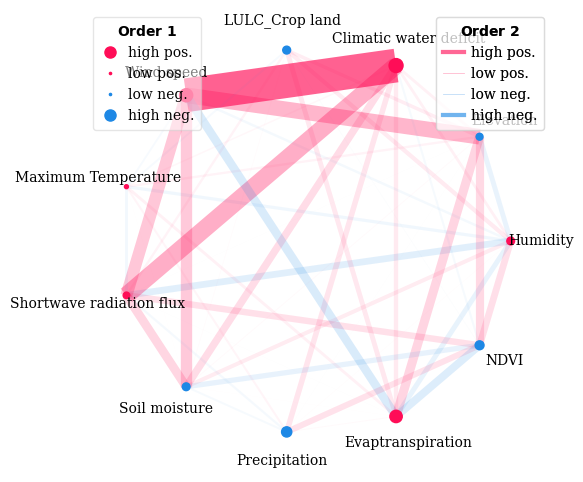

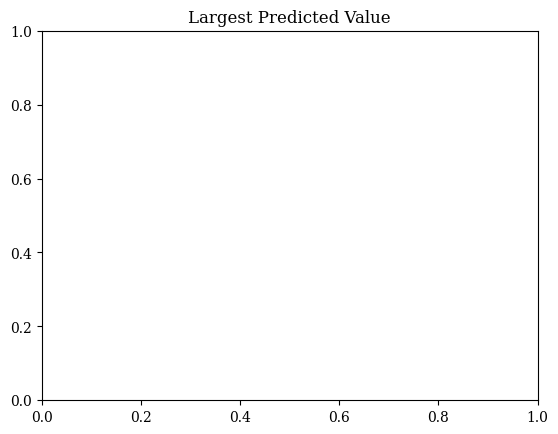

In [ ]:
import pandas as pd
import shapiq
import shap
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Set up fonts
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

# Convert X_train_selected to DataFrame
X_train_df = pd.DataFrame(X_train_selected, columns=X_train_selected.columns)

# Convert X_train_selected to NumPy (Fix for ShapIQ)
X_train_np = X_train_selected.to_numpy()

# Train XGBoost model
xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.01, random_state=42)
xgb_model.fit(X_train_np, y_train)

# Initialize ShapIQ Explainer (for interaction values)
explainer = shapiq.TabularExplainer(model=xgb_model, data=X_train_np, index="k-SII", max_order=2)

# Compute SHAP values using SHAP library
shap_explainer = shap.TreeExplainer(xgb_model)
shap_values = shap_explainer.shap_values(X_train_np)

# Compute interaction values for specific test samples (smallest & largest predictions)
y_pred = xgb_model.predict(X_val_selected)
smallest_idx = y_pred.argmin()  # Find index of lowest predicted value
largest_idx = y_pred.argmax()   # Find index of highest predicted value

# Convert X_val_selected to NumPy (Fix for ShapIQ)
X_val_np = pd.DataFrame(X_val_selected, columns=X_train_selected.columns).to_numpy()

interaction_values_low = explainer.explain(X_val_np[[smallest_idx]], budget=256)
interaction_values_high = explainer.explain(X_val_np[[largest_idx]], budget=256)

# Create a figure for side-by-side plots
plt.figure(figsize=(14, 6))

# Plot first network (Smallest Predicted Value)
plt.subplot(1, 2, 1)
interaction_values_low.plot_network(feature_names=X_train_selected.columns)
plt.title("Smallest Predicted Value")

# Plot second network (Largest Predicted Value)
plt.subplot(1, 2, 2)
interaction_values_high.plot_network(feature_names=X_train_selected.columns)
plt.title("Largest Predicted Value")

# Save the figure as an SVG file
plt.savefig("shap_interaction_network.svg", format="svg", bbox_inches="tight")
plt.show()


In [ ]:
X_train_selected

,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,-0.830688,-0.218214,1.324667,1.233257,0.604156,0.525807,1.011842,1.087708,0.968376,-0.510223,0.0
1,0.799524,-0.608056,-0.370016,-0.294047,1.017434,-0.709690,-1.102476,-0.675711,-0.280618,-0.916858,0.0
2,0.381872,0.110216,-1.291088,-1.113203,-0.357949,-0.914405,0.421268,-0.950878,-1.403284,1.456970,0.0
3,0.146703,-0.910844,0.775335,0.455542,0.283155,0.643507,0.171739,0.804901,0.605509,-0.733315,0.0
4,0.217869,-0.477207,-1.851333,-1.947729,-1.700576,-0.821806,-1.404596,-0.860161,-2.167361,0.929469,0.0
...,...,...,...,...,...,...,...,...,...,...,...
6752,-1.059826,2.613653,0.129962,-0.777020,-1.159355,2.265296,2.062632,-0.976687,0.556034,-0.915788,0.0
6753,-1.073705,0.206899,0.010595,-0.112351,-0.765094,0.719909,-0.368427,0.147929,-0.118446,0.267178,0.0
6754,0.772862,-0.631607,-0.328959,-0.189129,1.096721,-0.668200,-1.059448,-0.703959,-0.274567,-0.925872,0.0
6755,-0.718586,-0.904886,2.480092,2.108879,-0.616236,2.267797,2.644844,1.327307,1.711243,0.174134,0.0


In [ ]:
X_test_selected

,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,0.370637,-0.121730,-1.176259,-1.962385,-0.648101,-0.958061,0.392042,-1.023297,-1.360257,1.350602,0.0
1,3.781663,0.601709,0.849827,-0.330816,2.898495,-0.843171,-1.336715,2.155184,1.679785,0.727194,0.0
2,0.161464,0.090333,0.556241,0.759572,1.203045,-0.246458,0.730078,1.315495,0.815951,-0.203486,0.0
3,1.193754,-0.567825,-0.773498,0.070655,0.542157,-0.976770,-1.172152,-2.103163,-0.934863,-1.075020,0.0
4,0.290762,-0.214656,-0.157417,0.002949,0.458952,-0.252929,-0.443595,0.296875,-0.459257,0.113335,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1444,0.660906,0.549615,0.496612,-0.204269,1.537486,-0.323004,0.411520,1.452371,0.851480,0.235403,1.0
1445,-0.384778,-0.259187,0.143624,0.614816,0.388984,-0.183081,0.296269,0.581223,0.044320,-0.324427,0.0
1446,0.106856,-0.819538,-1.330237,-0.646587,-1.301638,-1.076092,-0.265338,-1.195806,-1.560841,1.549243,0.0
1447,-0.107265,-0.357590,0.291792,0.334854,0.693211,-0.150542,0.037170,0.629824,0.184958,-0.367892,0.0


In [ ]:
X_val_selected

,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,-0.126140,1.110494,-0.304912,0.582934,0.159703,-0.636256,-1.185961,-1.438936,0.079180,-1.353503,0.0
1,-0.339928,-0.165704,0.268766,0.636158,0.708478,-0.086076,0.055748,0.684524,0.196598,-0.497706,0.0
2,-0.290365,2.496674,-1.120891,-0.899553,0.503083,-0.510606,-0.958539,-1.620331,-0.427356,-0.776555,0.0
3,-0.228464,-0.724010,-0.852744,-1.057689,-0.141586,-0.431916,0.028194,0.116277,-0.939732,1.281662,0.0
4,-0.747607,-0.415219,-0.472096,-0.439870,-0.373321,-0.269574,-0.068611,0.364672,-0.595013,0.853177,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1443,1.369458,-0.421318,-0.887655,-0.572499,0.478163,-0.904590,-1.077298,-0.912935,-0.809977,-0.140969,0.0
1444,0.502190,0.050326,-1.150496,-0.499219,0.283525,-0.906981,0.090928,-0.997231,-1.206735,0.415546,0.0
1445,0.839211,-0.211422,-1.258890,-1.123027,0.041634,-0.984818,-1.087965,-1.498772,-1.266287,0.716809,0.0
1446,1.936956,-0.866141,-0.539925,-0.012756,1.189711,-0.801626,-0.925062,-1.436754,-0.486344,-1.413691,0.0


In [ ]:
# Concatenate the index columns back with the selected features
X_train_final_with_indices = pd.concat([train_indices.reset_index(drop=True), X_train_selected.reset_index(drop=True)], axis=1)
X_val_final_with_indices = pd.concat([val_indices.reset_index(drop=True), X_val_selected.reset_index(drop=True)], axis=1)
X_test_final_with_indices = pd.concat([test_indices.reset_index(drop=True), X_test_selected.reset_index(drop=True)], axis=1)

# Save the updated datasets
X_train_final_with_indices.to_csv('X_train_final_with_indices.csv', index=False)
X_val_final_with_indices.to_csv('X_val_final_with_indices.csv', index=False)
X_test_final_with_indices.to_csv('X_test_final_with_indices.csv', index=False)


In [ ]:
X_train_final_with_indices

,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,20015,49.467217,-92.961333,0.000000,0.0,18.0,1.682080,-0.830688,-0.218214,1.324667,1.233257,0.604156,0.525807,1.011842,1.087708,0.968376,-0.510223,0.0
1,139903,63.133883,-119.294667,0.000000,0.0,0.0,-0.715007,0.799524,-0.608056,-0.370016,-0.294047,1.017434,-0.709690,-1.102476,-0.675711,-0.280618,-0.916858,0.0
2,161762,65.467217,-109.628000,72.111000,0.0,0.0,0.584173,0.381872,0.110216,-1.291088,-1.113203,-0.357949,-0.914405,0.421268,-0.950878,-1.403284,1.456970,0.0
3,35887,51.133883,-82.878000,0.000000,0.0,18.0,1.565920,0.146703,-0.910844,0.775335,0.455542,0.283155,0.643507,0.171739,0.804901,0.605509,-0.733315,0.0
4,174632,66.800550,-89.128000,436.834992,0.0,0.0,-0.672101,0.217869,-0.477207,-1.851333,-1.947729,-1.700576,-0.821806,-1.404596,-0.860161,-2.167361,0.929469,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6752,75708,55.133883,-128.378000,5.000000,0.0,0.0,-0.586667,-1.059826,2.613653,0.129962,-0.777020,-1.159355,2.265296,2.062632,-0.976687,0.556034,-0.915788,0.0
6753,58853,53.383883,-66.128000,0.000000,0.0,0.0,-1.131360,-1.073705,0.206899,0.010595,-0.112351,-0.765094,0.719909,-0.368427,0.147929,-0.118446,0.267178,0.0
6754,139231,63.050550,-119.628000,0.000000,0.0,0.0,-0.549935,0.772862,-0.631607,-0.328959,-0.189129,1.096721,-0.668200,-1.059448,-0.703959,-0.274567,-0.925872,0.0
6755,3663,45.550550,-64.294667,0.000000,8.0,0.0,0.371167,-0.718586,-0.904886,2.480092,2.108879,-0.616236,2.267797,2.644844,1.327307,1.711243,0.174134,0.0


In [ ]:
X_val_final_with_indices

,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,136443,62.717217,-133.211333,0.000000,0.0,18.0,1.957200,-0.126140,1.110494,-0.304912,0.582934,0.159703,-0.636256,-1.185961,-1.438936,0.079180,-1.353503,0.0
1,86252,56.300550,-104.044667,0.000000,0.0,18.0,-1.410000,-0.339928,-0.165704,0.268766,0.636158,0.708478,-0.086076,0.055748,0.684524,0.196598,-0.497706,0.0
2,154169,64.717217,-132.378000,5.000000,0.0,0.0,0.745807,-0.290365,2.496674,-1.120891,-0.899553,0.503083,-0.510606,-0.958539,-1.620331,-0.427356,-0.776555,0.0
3,113403,59.717217,-96.294667,0.000000,0.0,0.0,1.685580,-0.228464,-0.724010,-0.852744,-1.057689,-0.141586,-0.431916,0.028194,0.116277,-0.939732,1.281662,0.0
4,101251,58.133883,-97.711333,5.000000,0.0,0.0,0.666379,-0.747607,-0.415219,-0.472096,-0.439870,-0.373321,-0.269574,-0.068611,0.364672,-0.595013,0.853177,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1443,156859,64.967217,-115.961333,0.000000,0.0,0.0,-0.009367,1.369458,-0.421318,-0.887655,-0.572499,0.478163,-0.904590,-1.077298,-0.912935,-0.809977,-0.140969,0.0
1444,163194,65.633883,-114.878000,0.000000,0.0,17.0,-0.108571,0.502190,0.050326,-1.150496,-0.499219,0.283525,-0.906981,0.090928,-0.997231,-1.206735,0.415546,0.0
1445,182438,67.633883,-119.128000,60.827599,0.0,0.0,-0.645085,0.839211,-0.211422,-1.258890,-1.123027,0.041634,-0.984818,-1.087965,-1.498772,-1.266287,0.716809,0.0
1446,170006,66.383883,-131.711333,0.000000,0.0,0.0,0.518746,1.936956,-0.866141,-0.539925,-0.012756,1.189711,-0.801626,-0.925062,-1.436754,-0.486344,-1.413691,0.0


In [ ]:
X_test_final_with_indices

,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,164000,65.717217,-110.794667,80.622597,0.0,0.0,0.623167,0.370637,-0.121730,-1.176259,-1.962385,-0.648101,-0.958061,0.392042,-1.023297,-1.360257,1.350602,0.0
1,28077,50.383883,-111.628000,125.000000,13.0,0.0,-0.478534,3.781663,0.601709,0.849827,-0.330816,2.898495,-0.843171,-1.336715,2.155184,1.679785,0.727194,0.0
2,61804,53.717217,-106.628000,0.000000,0.0,18.0,1.254830,0.161464,0.090333,0.556241,0.759572,1.203045,-0.246458,0.730078,1.315495,0.815951,-0.203486,0.0
3,183745,67.800550,-139.961333,0.000000,1.0,0.0,-3.638680,1.193754,-0.567825,-0.773498,0.070655,0.542157,-0.976770,-1.172152,-2.103163,-0.934863,-1.075020,0.0
4,103834,58.467217,-102.628000,0.000000,4.0,18.0,-0.660333,0.290762,-0.214656,-0.157417,0.002949,0.458952,-0.252929,-0.443595,0.296875,-0.459257,0.113335,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1444,57531,53.300550,-107.878000,5.000000,15.0,0.0,1.257830,0.660906,0.549615,0.496612,-0.204269,1.537486,-0.323004,0.411520,1.452371,0.851480,0.235403,1.0
1445,89094,56.633883,-102.128000,0.000000,0.0,18.0,-0.693437,-0.384778,-0.259187,0.143624,0.614816,0.388984,-0.183081,0.296269,0.581223,0.044320,-0.324427,0.0
1446,173585,66.717217,-106.961333,18.027800,0.0,0.0,0.102763,0.106856,-0.819538,-1.330237,-0.646587,-1.301638,-1.076092,-0.265338,-1.195806,-1.560841,1.549243,0.0
1447,84162,56.050550,-102.211333,0.000000,0.0,0.0,-0.584083,-0.107265,-0.357590,0.291792,0.334854,0.693211,-0.150542,0.037170,0.629824,0.184958,-0.367892,0.0


In [ ]:
X_train_final_with_indices

,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,20015,49.467217,-92.961333,0.000000,0.0,18.0,1.682080,-0.830688,-0.218214,1.324667,1.233257,0.604156,0.525807,1.011842,1.087708,0.968376,-0.510223,0.0
1,139903,63.133883,-119.294667,0.000000,0.0,0.0,-0.715007,0.799524,-0.608056,-0.370016,-0.294047,1.017434,-0.709690,-1.102476,-0.675711,-0.280618,-0.916858,0.0
2,161762,65.467217,-109.628000,72.111000,0.0,0.0,0.584173,0.381872,0.110216,-1.291088,-1.113203,-0.357949,-0.914405,0.421268,-0.950878,-1.403284,1.456970,0.0
3,35887,51.133883,-82.878000,0.000000,0.0,18.0,1.565920,0.146703,-0.910844,0.775335,0.455542,0.283155,0.643507,0.171739,0.804901,0.605509,-0.733315,0.0
4,174632,66.800550,-89.128000,436.834992,0.0,0.0,-0.672101,0.217869,-0.477207,-1.851333,-1.947729,-1.700576,-0.821806,-1.404596,-0.860161,-2.167361,0.929469,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6752,75708,55.133883,-128.378000,5.000000,0.0,0.0,-0.586667,-1.059826,2.613653,0.129962,-0.777020,-1.159355,2.265296,2.062632,-0.976687,0.556034,-0.915788,0.0
6753,58853,53.383883,-66.128000,0.000000,0.0,0.0,-1.131360,-1.073705,0.206899,0.010595,-0.112351,-0.765094,0.719909,-0.368427,0.147929,-0.118446,0.267178,0.0
6754,139231,63.050550,-119.628000,0.000000,0.0,0.0,-0.549935,0.772862,-0.631607,-0.328959,-0.189129,1.096721,-0.668200,-1.059448,-0.703959,-0.274567,-0.925872,0.0
6755,3663,45.550550,-64.294667,0.000000,8.0,0.0,0.371167,-0.718586,-0.904886,2.480092,2.108879,-0.616236,2.267797,2.644844,1.327307,1.711243,0.174134,0.0


In [ ]:
# Define the features to drop
features_to_drop = ['dist_fores', 'human_foot', 'pdsi', 'tree_speci']

# Load the datasets
train_file = "X_train_final_with_indices.csv"
val_file = "X_val_final_with_indices.csv"
test_file = "X_test_final_with_indices.csv"

X_train_final_with_indices = pd.read_csv(train_file)
X_val_final_with_indices = pd.read_csv(val_file)
X_test_final_with_indices = pd.read_csv(test_file)

# Drop the specified features
X_train_final_with_indices.drop(columns=features_to_drop, errors='ignore', inplace=True)
X_val_final_with_indices.drop(columns=features_to_drop, errors='ignore', inplace=True)
X_test_final_with_indices.drop(columns=features_to_drop, errors='ignore', inplace=True)

# Save the updated datasets
train_updated_file = "X_train_final_with_indices_updated.csv"
val_updated_file = "X_val_final_with_indices_updated.csv"
test_updated_file = "X_test_final_with_indices_updated.csv"

X_train_final_with_indices.to_csv(train_updated_file, index=False)
X_val_final_with_indices.to_csv(val_updated_file, index=False)
X_test_final_with_indices.to_csv(test_updated_file, index=False)



In [ ]:
X_train_final_with_indices

,point_id,lat_dd,long_dd,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,20015,49.467217,-92.961333,-0.830688,-0.218214,1.324667,1.233257,0.604156,0.525807,1.011842,1.087708,0.968376,-0.510223,0.0
1,139903,63.133883,-119.294667,0.799524,-0.608056,-0.370016,-0.294047,1.017434,-0.709690,-1.102476,-0.675711,-0.280618,-0.916858,0.0
2,161762,65.467217,-109.628000,0.381872,0.110216,-1.291088,-1.113203,-0.357949,-0.914405,0.421268,-0.950878,-1.403284,1.456970,0.0
3,35887,51.133883,-82.878000,0.146703,-0.910844,0.775335,0.455542,0.283155,0.643507,0.171739,0.804901,0.605509,-0.733315,0.0
4,174632,66.800550,-89.128000,0.217869,-0.477207,-1.851333,-1.947729,-1.700576,-0.821806,-1.404596,-0.860161,-2.167361,0.929469,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6752,75708,55.133883,-128.378000,-1.059826,2.613653,0.129962,-0.777020,-1.159355,2.265296,2.062632,-0.976687,0.556034,-0.915788,0.0
6753,58853,53.383883,-66.128000,-1.073705,0.206899,0.010595,-0.112351,-0.765094,0.719909,-0.368427,0.147929,-0.118446,0.267178,0.0
6754,139231,63.050550,-119.628000,0.772862,-0.631607,-0.328959,-0.189129,1.096721,-0.668200,-1.059448,-0.703959,-0.274567,-0.925872,0.0
6755,3663,45.550550,-64.294667,-0.718586,-0.904886,2.480092,2.108879,-0.616236,2.267797,2.644844,1.327307,1.711243,0.174134,0.0


In [ ]:
X_val_final_with_indices

,point_id,lat_dd,long_dd,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,136443,62.717217,-133.211333,-0.126140,1.110494,-0.304912,0.582934,0.159703,-0.636256,-1.185961,-1.438936,0.079180,-1.353503,0.0
1,86252,56.300550,-104.044667,-0.339928,-0.165704,0.268766,0.636158,0.708478,-0.086076,0.055748,0.684524,0.196598,-0.497706,0.0
2,154169,64.717217,-132.378000,-0.290365,2.496674,-1.120891,-0.899553,0.503083,-0.510606,-0.958539,-1.620331,-0.427356,-0.776555,0.0
3,113403,59.717217,-96.294667,-0.228464,-0.724010,-0.852744,-1.057689,-0.141586,-0.431916,0.028194,0.116277,-0.939732,1.281662,0.0
4,101251,58.133883,-97.711333,-0.747607,-0.415219,-0.472096,-0.439870,-0.373321,-0.269574,-0.068611,0.364672,-0.595013,0.853177,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1443,156859,64.967217,-115.961333,1.369458,-0.421318,-0.887655,-0.572499,0.478163,-0.904590,-1.077298,-0.912935,-0.809977,-0.140969,0.0
1444,163194,65.633883,-114.878000,0.502190,0.050326,-1.150496,-0.499219,0.283525,-0.906981,0.090928,-0.997231,-1.206735,0.415546,0.0
1445,182438,67.633883,-119.128000,0.839211,-0.211422,-1.258890,-1.123027,0.041634,-0.984818,-1.087965,-1.498772,-1.266287,0.716809,0.0
1446,170006,66.383883,-131.711333,1.936956,-0.866141,-0.539925,-0.012756,1.189711,-0.801626,-0.925062,-1.436754,-0.486344,-1.413691,0.0


In [ ]:
X_test_final_with_indices

,point_id,lat_dd,long_dd,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,164000,65.717217,-110.794667,0.370637,-0.121730,-1.176259,-1.962385,-0.648101,-0.958061,0.392042,-1.023297,-1.360257,1.350602,0.0
1,28077,50.383883,-111.628000,3.781663,0.601709,0.849827,-0.330816,2.898495,-0.843171,-1.336715,2.155184,1.679785,0.727194,0.0
2,61804,53.717217,-106.628000,0.161464,0.090333,0.556241,0.759572,1.203045,-0.246458,0.730078,1.315495,0.815951,-0.203486,0.0
3,183745,67.800550,-139.961333,1.193754,-0.567825,-0.773498,0.070655,0.542157,-0.976770,-1.172152,-2.103163,-0.934863,-1.075020,0.0
4,103834,58.467217,-102.628000,0.290762,-0.214656,-0.157417,0.002949,0.458952,-0.252929,-0.443595,0.296875,-0.459257,0.113335,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1444,57531,53.300550,-107.878000,0.660906,0.549615,0.496612,-0.204269,1.537486,-0.323004,0.411520,1.452371,0.851480,0.235403,1.0
1445,89094,56.633883,-102.128000,-0.384778,-0.259187,0.143624,0.614816,0.388984,-0.183081,0.296269,0.581223,0.044320,-0.324427,0.0
1446,173585,66.717217,-106.961333,0.106856,-0.819538,-1.330237,-0.646587,-1.301638,-1.076092,-0.265338,-1.195806,-1.560841,1.549243,0.0
1447,84162,56.050550,-102.211333,-0.107265,-0.357590,0.291792,0.334854,0.693211,-0.150542,0.037170,0.629824,0.184958,-0.367892,0.0


## K-fold spatial cross validation

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# Load dataset
train_file_path = "X_train_final_with_indices.csv"  # Update with your file path
X_train_final_with_indices = pd.read_csv(train_file_path)

# Extract latitude and longitude
coordinates = X_train_final_with_indices[['lat_dd', 'long_dd']]

# Apply K-Means clustering to assign 10 spatial regions
n_splits = 10
kmeans = KMeans(n_clusters=n_splits, random_state=42, n_init=10)
X_train_final_with_indices['spatial_fold'] = kmeans.fit_predict(coordinates)

# Save the corrected spatial folds dataset
X_train_final_with_indices.to_csv("X_train_final_with_corrected_spatial_folds.csv", index=False)

# Display unique fold values
print("Unique spatial folds assigned:", X_train_final_with_indices['spatial_fold'].unique())
print("Spatial folds have been reassigned and saved to 'X_train_final_with_corrected_spatial_folds.csv'.")


Unique spatial folds assigned: [1 8 2 7 6 3 9 5 4 0]
Spatial folds have been reassigned and saved to 'X_train_final_with_corrected_spatial_folds.csv'.


In [ ]:
tmp = pd.read_csv('X_train_final_with_corrected_spatial_folds.csv')
tmp

,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land,spatial_fold
0,20015,49.467217,-92.961333,0.000000,0.0,18.0,1.682080,-0.830688,-0.218214,1.324667,1.233257,0.604156,0.525807,1.011842,1.087708,0.968376,-0.510223,0.0,1
1,139903,63.133883,-119.294667,0.000000,0.0,0.0,-0.715007,0.799524,-0.608056,-0.370016,-0.294047,1.017434,-0.709690,-1.102476,-0.675711,-0.280618,-0.916858,0.0,8
2,161762,65.467217,-109.628000,72.111000,0.0,0.0,0.584173,0.381872,0.110216,-1.291088,-1.113203,-0.357949,-0.914405,0.421268,-0.950878,-1.403284,1.456970,0.0,2
3,35887,51.133883,-82.878000,0.000000,0.0,18.0,1.565920,0.146703,-0.910844,0.775335,0.455542,0.283155,0.643507,0.171739,0.804901,0.605509,-0.733315,0.0,1
4,174632,66.800550,-89.128000,436.834992,0.0,0.0,-0.672101,0.217869,-0.477207,-1.851333,-1.947729,-1.700576,-0.821806,-1.404596,-0.860161,-2.167361,0.929469,0.0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6752,75708,55.133883,-128.378000,5.000000,0.0,0.0,-0.586667,-1.059826,2.613653,0.129962,-0.777020,-1.159355,2.265296,2.062632,-0.976687,0.556034,-0.915788,0.0,4
6753,58853,53.383883,-66.128000,0.000000,0.0,0.0,-1.131360,-1.073705,0.206899,0.010595,-0.112351,-0.765094,0.719909,-0.368427,0.147929,-0.118446,0.267178,0.0,3
6754,139231,63.050550,-119.628000,0.000000,0.0,0.0,-0.549935,0.772862,-0.631607,-0.328959,-0.189129,1.096721,-0.668200,-1.059448,-0.703959,-0.274567,-0.925872,0.0,8
6755,3663,45.550550,-64.294667,0.000000,8.0,0.0,0.371167,-0.718586,-0.904886,2.480092,2.108879,-0.616236,2.267797,2.644844,1.327307,1.711243,0.174134,0.0,3


In [ ]:
tmp['spatial_fold'].value_counts(normalize=True)

,proportion
spatial_fold,
6,0.125943
9,0.114992
0,0.111588
5,0.107000
8,0.099600
2,0.098712
1,0.092201
3,0.090573
4,0.088353


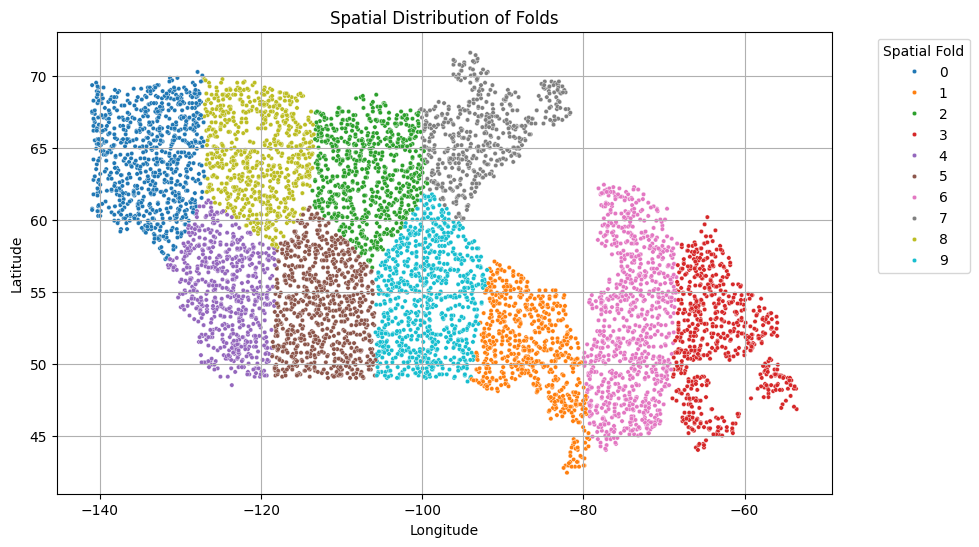

In [ ]:
# Scatter plot of spatial folds
plt.figure(figsize=(10, 6))
sns.scatterplot(x=tmp["long_dd"], y=tmp["lat_dd"], hue=tmp["spatial_fold"], palette="tab10", s=10)
plt.title("Spatial Distribution of Folds")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Spatial Fold", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

In [ ]:
X_train_final_with_indices.columns

Index(['point_id', 'lat_dd', 'long_dd', 'dist_fores', 'human_foot',
       'tree_speci', 'pdsi', 'Climatic water deficit', 'Elevation', 'Humidity',
       'NDVI', 'Evaptranspiration', 'Precipitation', 'Soil moisture',
       'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed',
       'LULC_Crop_land', 'spatial_fold'],
      dtype='object')

In [ ]:
X_test_final_with_indices.columns

Index(['point_id', 'lat_dd', 'long_dd', 'Climatic water deficit', 'Elevation',
       'Humidity', 'NDVI', 'Evaptranspiration', 'Precipitation',
       'Soil moisture', 'Shortwave radiation flux', 'Maximum Temperature',
       'Wind speed', 'LULC_Crop_land'],
      dtype='object')

In [ ]:
X_val_final_with_indices.columns

Index(['point_id', 'lat_dd', 'long_dd', 'Climatic water deficit', 'Elevation',
       'Humidity', 'NDVI', 'Evaptranspiration', 'Precipitation',
       'Soil moisture', 'Shortwave radiation flux', 'Maximum Temperature',
       'Wind speed', 'LULC_Crop_land'],
      dtype='object')

In [ ]:
# Define features to drop
drop_features = ["point_id", "lat_dd", "long_dd", "dist_fores", "human_foot", "tree_speci", "pdsi"]

# Load the datasets
train_file = "X_train_final_with_corrected_spatial_folds.csv"
val_file = "X_val_final_with_indices.csv"
test_file = "X_test_final_with_indices.csv"

X_train_final_with_indices = pd.read_csv(train_file)
X_val_final_with_indices = pd.read_csv(val_file)
X_test_final_with_indices = pd.read_csv(test_file)

# Drop the specified features from training, validation, and test datasets
X_train_final_with_indices.drop(columns=drop_features, errors='ignore', inplace=True)
X_val_final_with_indices.drop(columns=drop_features, errors='ignore', inplace=True)
X_test_final_with_indices.drop(columns=drop_features, errors='ignore', inplace=True)

# Save the cleaned datasets
X_train_final_with_indices.to_csv("X_train_final_cleaned.csv", index=False)
X_val_final_with_indices.to_csv("X_val_final_cleaned.csv", index=False)
X_test_final_with_indices.to_csv("X_test_final_cleaned.csv", index=False)



In [ ]:
X_train_final_with_indices

,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land,spatial_fold
0,-0.830688,-0.218214,1.324667,1.233257,0.604156,0.525807,1.011842,1.087708,0.968376,-0.510223,0.0,1
1,0.799524,-0.608056,-0.370016,-0.294047,1.017434,-0.709690,-1.102476,-0.675711,-0.280618,-0.916858,0.0,8
2,0.381872,0.110216,-1.291088,-1.113203,-0.357949,-0.914405,0.421268,-0.950878,-1.403284,1.456970,0.0,2
3,0.146703,-0.910844,0.775335,0.455542,0.283155,0.643507,0.171739,0.804901,0.605509,-0.733315,0.0,1
4,0.217869,-0.477207,-1.851333,-1.947729,-1.700576,-0.821806,-1.404596,-0.860161,-2.167361,0.929469,0.0,7
...,...,...,...,...,...,...,...,...,...,...,...,...
6752,-1.059826,2.613653,0.129962,-0.777020,-1.159355,2.265296,2.062632,-0.976687,0.556034,-0.915788,0.0,4
6753,-1.073705,0.206899,0.010595,-0.112351,-0.765094,0.719909,-0.368427,0.147929,-0.118446,0.267178,0.0,3
6754,0.772862,-0.631607,-0.328959,-0.189129,1.096721,-0.668200,-1.059448,-0.703959,-0.274567,-0.925872,0.0,8
6755,-0.718586,-0.904886,2.480092,2.108879,-0.616236,2.267797,2.644844,1.327307,1.711243,0.174134,0.0,3


In [ ]:
X_val_final_with_indices

,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,-0.126140,1.110494,-0.304912,0.582934,0.159703,-0.636256,-1.185961,-1.438936,0.079180,-1.353503,0.0
1,-0.339928,-0.165704,0.268766,0.636158,0.708478,-0.086076,0.055748,0.684524,0.196598,-0.497706,0.0
2,-0.290365,2.496674,-1.120891,-0.899553,0.503083,-0.510606,-0.958539,-1.620331,-0.427356,-0.776555,0.0
3,-0.228464,-0.724010,-0.852744,-1.057689,-0.141586,-0.431916,0.028194,0.116277,-0.939732,1.281662,0.0
4,-0.747607,-0.415219,-0.472096,-0.439870,-0.373321,-0.269574,-0.068611,0.364672,-0.595013,0.853177,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1443,1.369458,-0.421318,-0.887655,-0.572499,0.478163,-0.904590,-1.077298,-0.912935,-0.809977,-0.140969,0.0
1444,0.502190,0.050326,-1.150496,-0.499219,0.283525,-0.906981,0.090928,-0.997231,-1.206735,0.415546,0.0
1445,0.839211,-0.211422,-1.258890,-1.123027,0.041634,-0.984818,-1.087965,-1.498772,-1.266287,0.716809,0.0
1446,1.936956,-0.866141,-0.539925,-0.012756,1.189711,-0.801626,-0.925062,-1.436754,-0.486344,-1.413691,0.0


In [ ]:
X_test_final_with_indices

,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,0.370637,-0.121730,-1.176259,-1.962385,-0.648101,-0.958061,0.392042,-1.023297,-1.360257,1.350602,0.0
1,3.781663,0.601709,0.849827,-0.330816,2.898495,-0.843171,-1.336715,2.155184,1.679785,0.727194,0.0
2,0.161464,0.090333,0.556241,0.759572,1.203045,-0.246458,0.730078,1.315495,0.815951,-0.203486,0.0
3,1.193754,-0.567825,-0.773498,0.070655,0.542157,-0.976770,-1.172152,-2.103163,-0.934863,-1.075020,0.0
4,0.290762,-0.214656,-0.157417,0.002949,0.458952,-0.252929,-0.443595,0.296875,-0.459257,0.113335,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1444,0.660906,0.549615,0.496612,-0.204269,1.537486,-0.323004,0.411520,1.452371,0.851480,0.235403,1.0
1445,-0.384778,-0.259187,0.143624,0.614816,0.388984,-0.183081,0.296269,0.581223,0.044320,-0.324427,0.0
1446,0.106856,-0.819538,-1.330237,-0.646587,-1.301638,-1.076092,-0.265338,-1.195806,-1.560841,1.549243,0.0
1447,-0.107265,-0.357590,0.291792,0.334854,0.693211,-0.150542,0.037170,0.629824,0.184958,-0.367892,0.0


In [ ]:
X_train_final_with_indices.shape

(6757, 12)

In [ ]:
y_train.shape

(6757,)

## 10-fold spatial cross-validation splitting

In [ ]:
# Ensure indices are aligned
X_train_final_with_indices = X_train_final_with_indices.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

# Extract unique spatial folds
unique_folds = sorted(X_train_final_with_indices["spatial_fold"].unique())

# Prepare to store spatial fold splits
spatial_cv_splits = []

# Perform 10-Fold Spatial Cross-Validation Splitting
for fold in unique_folds:
    print(f"🔹 Preparing Fold {fold}...")

    # Define train and validation sets based on spatial fold
    train_data = X_train_final_with_indices[X_train_final_with_indices["spatial_fold"] != fold]
    val_data = X_train_final_with_indices[X_train_final_with_indices["spatial_fold"] == fold]

    # Extract train and validation indices
    train_indices = train_data.index
    val_indices = val_data.index

    # Drop "spatial_fold" from feature sets
    X_train_fold = train_data.drop(columns=["spatial_fold"])
    X_val_fold = val_data.drop(columns=["spatial_fold"])

    # Extract corresponding target values
    y_train_fold = y_train.iloc[train_indices]
    y_val_fold = y_train.iloc[val_indices]

    # Store the train-validation split for this fold
    spatial_cv_splits.append({
        "fold": fold,
        "X_train": X_train_fold,
        "y_train": y_train_fold,
        "X_val": X_val_fold,
        "y_val": y_val_fold
    })

print(f"\n✅ 10-Fold Spatial Cross-Validation Splits Prepared ({len(spatial_cv_splits)} Folds)")


🔹 Preparing Fold 0...
🔹 Preparing Fold 1...
🔹 Preparing Fold 2...
🔹 Preparing Fold 3...
🔹 Preparing Fold 4...
🔹 Preparing Fold 5...
🔹 Preparing Fold 6...
🔹 Preparing Fold 7...
🔹 Preparing Fold 8...
🔹 Preparing Fold 9...

✅ 10-Fold Spatial Cross-Validation Splits Prepared (10 Folds)


In [ ]:
X_train.shape

(6757, 13)

In [ ]:
y_train.shape

(6757,)

In [ ]:
X_train_fold.shape

(5980, 11)

In [ ]:
y_train_fold.shape

(5980,)

In [ ]:
 X_val_fold.shape

(777, 11)

In [ ]:
X_train_fold.head()

,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,-0.830688,-0.218214,1.324667,1.233257,0.604156,0.525807,1.011842,1.087708,0.968376,-0.510223,0.0
1,0.799524,-0.608056,-0.370016,-0.294047,1.017434,-0.709690,-1.102476,-0.675711,-0.280618,-0.916858,0.0
2,0.381872,0.110216,-1.291088,-1.113203,-0.357949,-0.914405,0.421268,-0.950878,-1.403284,1.456970,0.0
3,0.146703,-0.910844,0.775335,0.455542,0.283155,0.643507,0.171739,0.804901,0.605509,-0.733315,0.0
4,0.217869,-0.477207,-1.851333,-1.947729,-1.700576,-0.821806,-1.404596,-0.860161,-2.167361,0.929469,0.0


### Approach

1. Spatial K-fold cross-validation is for model selection, NOT Final training

* In spatial K-fold CV, we train on 9 folds and validate on 1 fold.
* each model in spatial CV is trained on only 90% of the trainig data, which means it does not fully utilize all available training data.
2. Final Model should be trained on FULL training data.
* Once we determine the best model, we should train it on 100% of the training data
* This ensures the model learns all available patterns.

# Deep Neural Network

### Train DNN model using 10-fold CV

This code ensures that each fold is used for validation once, while the remaining 9 folds are used for training.

1. 10-Fold Spatial Cross-Validation

* Train on 9 folds, validate on 1 fold.
* Repeat for each fold.
* Store validation metrics.
2. Train the Final Model

* Use full training dataset (X_train_final_with_indices).
* Validate using separate validation data (X_val_final_with_indices).
3. Evaluate on the Test Set

* Measure performance on unseen test data (X_test_final_with_indices).

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define a function to create the DNN model
def create_dnn(input_shape, dropout_rate=0.1):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_shape,)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')  # Output layer for regression
    ])
    return model

# Compile the model
def compile_dnn(model, learning_rate=0.001):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse',  # Mean Squared Error for regression
                  metrics=['mae'])  # Mean Absolute Error as an additional metric
    return model

# Store cross-validation results
cv_results = []

# Perform 10-Fold Spatial Cross-Validation
for fold_split in spatial_cv_splits:
    fold = fold_split["fold"]
    X_train_fold = fold_split["X_train"]
    y_train_fold = fold_split["y_train"]
    X_val_fold = fold_split["X_val"]
    y_val_fold = fold_split["y_val"]

    print(f"\n🔹 Training Fold {fold} (Train on 9 folds, Validate on 1 fold)...")

    # Define input shape
    input_shape = X_train_fold.shape[1]

    # Create and compile the DNN model
    dnn_model = create_dnn(input_shape)
    dnn_model = compile_dnn(dnn_model)

    # Train the model
    history = dnn_model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=50,
        batch_size=32,
        verbose=1
    )

    # Evaluate the model on the validation set
    val_loss, val_mae = dnn_model.evaluate(X_val_fold, y_val_fold, verbose=0)

    # Make predictions on the validation set
    y_pred_val = dnn_model.predict(X_val_fold)

    # Calculate regression metrics
    mse = mean_squared_error(y_val_fold, y_pred_val)
    mae = mean_absolute_error(y_val_fold, y_pred_val)
    r2 = r2_score(y_val_fold, y_pred_val)

    # Store results
    cv_results.append({
        "Fold": fold,
        "Validation MSE": mse,
        "Validation MAE": mae,
        "Validation R²": r2
    })

    print(f"✅ Fold {fold} Results: MSE={mse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")

# Convert results to DataFrame and display
cv_results_df = pd.DataFrame(cv_results)
print("\n📊 Cross-Validation Results:\n", cv_results_df)



🔹 Training Fold 0 (Train on 9 folds, Validate on 1 fold)...
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


188/188 ━━━━━━━━━━━━━━━━━━━━ 45s 4ms/step - loss: 0.0059 - mae: 0.0538 - val_loss: 8.4479e-04 - val_mae: 0.0227
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9.2330e-04 - mae: 0.0222 - val_loss: 5.9609e-04 - val_mae: 0.0184
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.0356e-04 - mae: 0.0189 - val_loss: 4.6770e-04 - val_mae: 0.0167
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.6574e-04 - mae: 0.0168 - val_loss: 5.8070e-04 - val_mae: 0.0173
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.1104e-04 - mae: 0.0157 - val_loss: 5.5145e-04 - val_mae: 0.0168
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.9479e-04 - mae: 0.0150 - val_loss: 3.9365e-04 - val_mae: 0.0146
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.9165e-04 - mae: 0.0148 - val_loss: 3.9716e-04 - val_mae: 0.0144
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.6522e-04 - mae: 0.0141 - val_loss: 4.2795e-04 - val_mae: 0.0159
Epoch 

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0116 - mae: 0.0727 - val_loss: 6.8104e-04 - val_mae: 0.0215
Epoch 2/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0012 - mae: 0.0264 - val_loss: 6.2745e-04 - val_mae: 0.0212
Epoch 3/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 8.5764e-04 - mae: 0.0212 - val_loss: 7.6194e-04 - val_mae: 0.0238
Epoch 4/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.0612e-04 - mae: 0.0187 - val_loss: 8.6076e-04 - val_mae: 0.0251
Epoch 5/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.0524e-04 - mae: 0.0180 - val_loss: 3.5802e-04 - val_mae: 0.0150
Epoch 6/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5.9932e-04 - mae: 0.0167 - val_loss: 7.2119e-04 - val_mae: 0.0232
Epoch 7/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.7069e-04 - mae: 0.0163 - val_loss: 6.7586e-04 - val_mae: 0.0217
Epoch 8/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.4386e-04 - mae: 0.0157 - val_loss: 4.9861e-04 - val_mae: 0.0179
Epoch 9/50


...

197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0078 - mae: 0.0585 - val_loss: 1.7159e-04 - val_mae: 0.0095
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 9.9445e-04 - mae: 0.0234 - val_loss: 8.7689e-05 - val_mae: 0.0078
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.8064e-04 - mae: 0.0200 - val_loss: 3.4710e-05 - val_mae: 0.0046
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.6816e-04 - mae: 0.0182 - val_loss: 2.7392e-05 - val_mae: 0.0044
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.9304e-04 - mae: 0.0172 - val_loss: 3.4255e-05 - val_mae: 0.0048
Epoch 6/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.2916e-04 - mae: 0.0160 - val_loss: 6.6022e-05 - val_mae: 0.0072
Epoch 7/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.0239e-04 - mae: 0.0156 - val_loss: 7.3973e-06 - val_mae: 0.0020
Epoch 8/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.9041e-04 - mae: 0.0152 - val_loss: 1.5859e-05 - val_mae: 0.0031
Epoch 9

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0073 - mae: 0.0560 - val_loss: 5.7670e-04 - val_mae: 0.0171
Epoch 2/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0010 - mae: 0.0238 - val_loss: 5.7867e-04 - val_mae: 0.0166
Epoch 3/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.0906e-04 - mae: 0.0193 - val_loss: 5.2481e-04 - val_mae: 0.0159
Epoch 4/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.0900e-04 - mae: 0.0174 - val_loss: 5.0932e-04 - val_mae: 0.0156
Epoch 5/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.3613e-04 - mae: 0.0164 - val_loss: 5.4148e-04 - val_mae: 0.0169
Epoch 6/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5.0911e-04 - mae: 0.0156 - val_loss: 5.4428e-04 - val_mae: 0.0167
Epoch 7/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.7022e-04 - mae: 0.0148 - val_loss: 5.4215e-04 - val_mae: 0.0154
Epoch 8/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.6040e-04 - mae: 0.0148 - val_loss: 5.9815e-04 - val_mae: 0.0177
Epoch 9/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0117 - mae: 0.0698 - val_loss: 0.0024 - val_mae: 0.0345
Epoch 2/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0010 - mae: 0.0231 - val_loss: 0.0020 - val_mae: 0.0305
Epoch 3/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.1779e-04 - mae: 0.0190 - val_loss: 0.0019 - val_mae: 0.0274
Epoch 4/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.9389e-04 - mae: 0.0167 - val_loss: 0.0017 - val_mae: 0.0263
Epoch 5/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.0742e-04 - mae: 0.0155 - val_loss: 0.0016 - val_mae: 0.0252
Epoch 6/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.1069e-04 - mae: 0.0152 - val_loss: 0.0016 - val_mae: 0.0242
Epoch 7/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.3984e-04 - mae: 0.0141 - val_loss: 0.0014 - val_mae: 0.0230
Epoch 8/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.1373e-04 - mae: 0.0138 - val_loss: 0.0016 - val_mae: 0.0239
Epoch 9/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 

In [ ]:
print("\n🚀 Training Final DNN Model on Full Training Data...")

# Load full training data
X_train_full = X_train_final_with_indices.drop(columns=["spatial_fold"])
y_train_full = y_train

# Define and compile the final model
input_shape = X_train_full.shape[1]
final_dnn_model = create_dnn(input_shape)
final_dnn_model = compile_dnn(final_dnn_model)

history_final = final_dnn_model.fit(
    X_train_full, y_train_full,
    validation_data=(X_val_final_with_indices, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

# Save the trained model
final_dnn_model.save('final_dnn_regression_model.h5')



🚀 Training Final DNN Model on Full Training Data...
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0090 - mae: 0.0600 - val_loss: 6.3587e-04 - val_mae: 0.0182
Epoch 2/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9.9127e-04 - mae: 0.0227 - val_loss: 5.1442e-04 - val_mae: 0.0152
Epoch 3/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.3878e-04 - mae: 0.0192 - val_loss: 4.3109e-04 - val_mae: 0.0142
Epoch 4/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.3777e-04 - mae: 0.0178 - val_loss: 4.1445e-04 - val_mae: 0.0128
Epoch 5/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.9505e-04 - mae: 0.0168 - val_loss: 3.7350e-04 - val_mae: 0.0121
Epoch 6/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.6357e-04 - mae: 0.0161 - val_loss: 3.7371e-04 - val_mae: 0.0137
Epoch 7/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.7076e-04 - mae: 0.0150 - val_loss: 3.4820e-04 - val_mae: 0.0125
Epoch 8/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.0430e-04 - mae: 0.0152 - val_loss: 3.5406e-04 - val_mae: 0.0126
Epoch 9

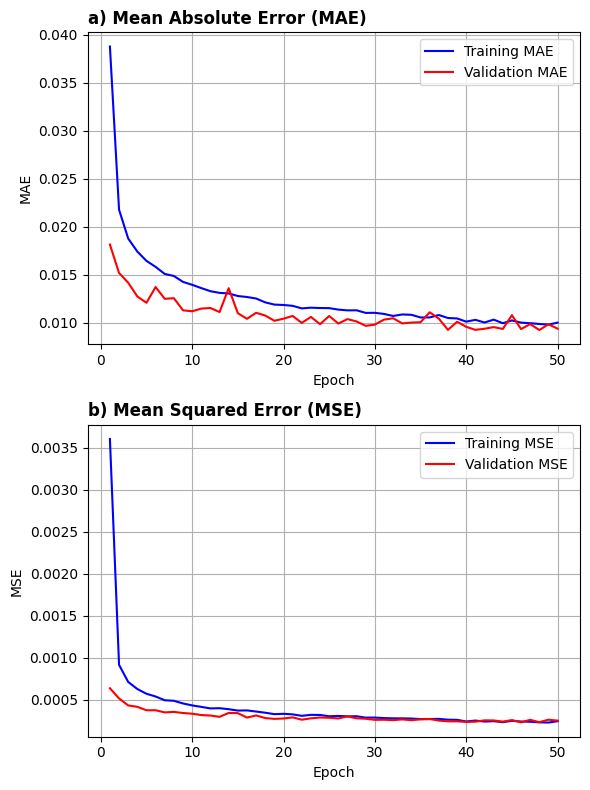

In [ ]:
import matplotlib.pyplot as plt

def plot_training_validation_metrics(history):
    epochs = range(1, len(history.history['loss']) + 1)

    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_mse = history.history['loss']
    val_mse = history.history['val_loss']

    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    # Plot MAE
    axes[0].plot(epochs, train_mae, label='Training MAE', color='blue')
    axes[0].plot(epochs, val_mae, label='Validation MAE', color='red')
    axes[0].set_title('a) Mean Absolute Error (MAE)', loc='left', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MAE')
    axes[0].legend()
    axes[0].grid()

    # Plot MSE
    axes[1].plot(epochs, train_mse, label='Training MSE', color='blue')
    axes[1].plot(epochs, val_mse, label='Validation MSE', color='red')
    axes[1].set_title('b) Mean Squared Error (MSE)', loc='left', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MSE')
    axes[1].legend()
    axes[1].grid()

    plt.tight_layout()
    plt.show()

# Call the function to plot training and validation metrics
plot_training_validation_metrics(history_final)


# TEST PREDICTION

In [ ]:
# Load unseen data
df_unseen = pd.read_csv(
    'large_fires_data_v2_predictions.csv',
    names= [
        'point_id',
        'lat_dd',
        'long_dd',
        'Aspect',
        'Climatic water deficit',
        'Elevation',
        'Humidity',
        'LULC',
        'NDVI',
        'Evaptranspiration',
        'Precipitation',
        'Slope',
        'Soil moisture',
        'Shortwave radiation flux',
        'Maximum Temperature',
        'Wind speed',
        'dist_fores',
        'human_foot',
        'tree_speci',
        'pdsi'
    ],
    header= 0
)

# Replace -9999 with NaN
df_unseen.replace(-9999, np.nan, inplace=True)

# Fill missing values using forward fill, then backward fill
df_unseen.fillna(method='ffill', inplace=True)
df_unseen.fillna(method='bfill', inplace=True)


replace_values_LULC = {
    1: 'Urban_areas',
    2: 'Crop_land',
    3: 'Grass_land',
    4: 'Tree_covered',
    5: 'Shrub_covered',
    6: 'Herbaceous',
    8: 'Sparse_vegetation',
    9: 'Bare_soil',
    10: 'Snow',
    11: 'Water_bodies',
}

df_unseen['LULC'] = df_unseen['LULC'].replace(replace_values_LULC)
# Convert necessary columns to categorical
df_unseen = df_unseen.astype(
    {
        'LULC': 'category'
    }
)

# Define categorical, numerical, and additional columns
categorical_columns = ['LULC']
numerical_columns = [
    'Climatic water deficit', 'Elevation', 'Humidity', 'NDVI',
    'Evaptranspiration', 'Precipitation', 'Slope', 'Soil moisture',
    'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed'
]
additional_columns = ['point_id', 'lat_dd', 'long_dd', 'dist_fores', 'human_foot', 'tree_speci', 'pdsi']  # Columns to retain

# Apply the trained encoder and scaler
X_unseen_encoded = pd.DataFrame(encoder.transform(df_unseen[categorical_columns]),
                                columns=encoder.get_feature_names_out(categorical_columns))
X_unseen_scaled = pd.DataFrame(scaler.transform(df_unseen[numerical_columns]), columns=numerical_columns)

# Concatenate encoded categorical and scaled numerical features
X_unseen_final = pd.concat([X_unseen_scaled.reset_index(drop=True), X_unseen_encoded.reset_index(drop=True)], axis=1)

# Save the processed unseen data to a CSV file
X_unseen_final.to_csv('unseen_data_preprocessed.csv', index=False)

# Display the first few rows of the processed data
X_unseen_final.head()


# Extract additional columns from the original unseen dataframe
X_unseen_additional = df_unseen[additional_columns].reset_index(drop=True)

# Concatenate processed numerical, encoded categorical, and additional columns
X_unseen_final = pd.concat([X_unseen_additional, X_unseen_scaled.reset_index(drop=True), X_unseen_encoded.reset_index(drop=True)], axis=1)

# Save the final processed unseen data to a CSV file
X_unseen_final.to_csv('unseen_data_preprocessed.csv', index=False)


# Define features to be removed
features_to_remove = [
    'Slope', 'LULC_Bare_soil', 'LULC_Grass_land', 'LULC_Herbaceous',
    'LULC_Shrub_covered', 'LULC_Snow', 'LULC_Sparse_vegetation',
    'LULC_Tree_covered', 'LULC_Urban_areas', 'LULC_Water_bodies']

# Drop the selected features from the unseen dataset
X_unseen_final_selected = X_unseen_final.drop(columns=features_to_remove, errors='ignore')

# Save the final feature-selected unseen dataset to a CSV file
X_unseen_final_selected.to_csv('unseen_data_preprocessed_selected.csv', index=False)

# Display the first few rows of the final dataset
X_unseen_final_selected.head()

<ipython-input-77-d0ed9f7ab97c>:33: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_unseen.fillna(method='ffill', inplace=True)
<ipython-input-77-d0ed9f7ab97c>:34: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_unseen.fillna(method='bfill', inplace=True)


,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,12493,48.383883,-123.961333,0.0,18.0,0.0,-1.644420,0.220652,-0.635412,3.571901,2.948433,-1.452216,5.118402,9.949277,0.573263,1.803726,-0.227430,0.0
1,12494,48.383883,-123.878000,0.0,18.0,0.0,-1.360750,0.488200,-0.635412,3.571901,2.948433,-1.290211,4.190799,9.109807,0.649534,1.954714,-0.272971,0.0
2,12495,48.383883,-123.794667,0.0,18.0,0.0,-1.257080,0.467257,-0.635412,3.571901,2.948433,-1.300138,4.052230,8.696123,0.623468,1.874057,-0.389329,0.0
3,12497,48.383883,-123.628000,0.0,18.0,30.0,-0.977667,0.830044,-0.635412,3.571901,3.504778,-1.167773,2.998933,7.524046,0.652037,1.918102,-0.375554,0.0
4,12498,48.383883,-123.544667,0.0,41.0,0.0,-0.797250,1.395641,-0.635412,3.556090,2.821264,-0.957905,1.722572,6.597038,0.698134,2.090593,-0.373367,0.0


In [ ]:
from tensorflow.keras.models import load_model
import tensorflow.keras.losses
import pandas as pd

# Load the trained DNN model
custom_objects = {"mse": tensorflow.keras.losses.MeanSquaredError()}
final_dnn_model = load_model('final_dnn_regression_model.h5', custom_objects=custom_objects)

# Load preprocessed unseen data
X_unseen_final_selected = pd.read_csv('unseen_data_preprocessed_selected.csv')

# Define and extract features
features_for_prediction = [
    'Climatic water deficit', 'Elevation', 'Humidity',
    'NDVI', 'Evaptranspiration', 'Precipitation', 'Soil moisture',
    'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed', 'LULC_Crop_land'
]

X_unseen_for_prediction = X_unseen_final_selected[features_for_prediction]

# Make predictions
predictions = final_dnn_model.predict(X_unseen_for_prediction).reshape(-1)

# Rename the target feature and format to 4 decimal places
X_unseen_final_selected['wildfire_proba'] = predictions.round(4)

# Keep only reference columns and the target feature
additional_features = ['point_id', 'lat_dd', 'long_dd', 'dist_fores', 'human_foot', 'tree_speci', 'pdsi']
final_unseen_results = X_unseen_final_selected[additional_features + ['wildfire_proba']]

# Save the results to a CSV file
final_unseen_results.to_csv('unseen_data_with_wildfire_proba_DNN.csv', index=False)

# Display first few rows of predictions
print(final_unseen_results.head())


5172/5172 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
   point_id     lat_dd     long_dd  dist_fores  human_foot  tree_speci  \
0     12493  48.383883 -123.961333         0.0        18.0         0.0   
1     12494  48.383883 -123.878000         0.0        18.0         0.0   
2     12495  48.383883 -123.794667         0.0        18.0         0.0   
3     12497  48.383883 -123.628000         0.0        18.0        30.0   
4     12498  48.383883 -123.544667         0.0        41.0         0.0   

       pdsi  wildfire_proba  
0 -1.644420          0.0303  
1 -1.360750          0.0277  
2 -1.257080          0.0307  
3 -0.977667          0.0183  
4 -0.797250          0.0244  


# TEST BLOCK IS FINISHED

# BiRNN hyperparameter optimization (Grid Search with spatial 10-fold cv)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Bidirectional, SimpleRNN
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define a function to create the BiRNN model
def create_birnn(input_shape, dropout_rate=0.1):
    model = Sequential([
        Bidirectional(SimpleRNN(128, activation='relu', return_sequences=True), input_shape=(input_shape, 1)),
        Dropout(dropout_rate),
        Bidirectional(SimpleRNN(64, activation='relu')),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')  # Output layer for regression
    ])
    return model

# Compile the model
def compile_birnn(model, learning_rate=0.001):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse',  # Mean Squared Error for regression
                  metrics=['mae'])  # Mean Absolute Error as an additional metric
    return model


In [ ]:
# Store cross-validation results
cv_results = []

# Perform 10-Fold Spatial Cross-Validation
for fold_split in spatial_cv_splits:
    fold = fold_split["fold"]
    X_train_fold = fold_split["X_train"]
    y_train_fold = fold_split["y_train"]
    X_val_fold = fold_split["X_val"]
    y_val_fold = fold_split["y_val"]

    print(f"\n🔹 Training Fold {fold} (Train on 9 folds, Validate on 1 fold)...")

    # Reshape input data for BiRNN (RNNs expect 3D input: (samples, timesteps, features))
    X_train_fold = X_train_fold.values.reshape((X_train_fold.shape[0], X_train_fold.shape[1], 1))
    X_val_fold = X_val_fold.values.reshape((X_val_fold.shape[0], X_val_fold.shape[1], 1))

    # Define input shape
    input_shape = X_train_fold.shape[1]

    # Create and compile the BiRNN model
    birnn_model = create_birnn(input_shape)
    birnn_model = compile_birnn(birnn_model)

    # Train the model
    history = birnn_model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=50,
        batch_size=32,
        verbose=1
    )

    # Evaluate the model on the validation set
    val_loss, val_mae = birnn_model.evaluate(X_val_fold, y_val_fold, verbose=0)

    # Make predictions on the validation set
    y_pred_val = birnn_model.predict(X_val_fold)

    # Calculate regression metrics
    mse = mean_squared_error(y_val_fold, y_pred_val)
    mae = mean_absolute_error(y_val_fold, y_pred_val)
    r2 = r2_score(y_val_fold, y_pred_val)

    # Store results
    cv_results.append({
        "Fold": fold,
        "Validation MSE": mse,
        "Validation MAE": mae,
        "Validation R²": r2
    })

    print(f"✅ Fold {fold} Results: MSE={mse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")

# Convert results to DataFrame and display
cv_results_df = pd.DataFrame(cv_results)
print("\n📊 Cross-Validation Results:\n", cv_results_df)



🔹 Training Fold 0 (Train on 9 folds, Validate on 1 fold)...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 27s 46ms/step - loss: 0.0054 - mae: 0.0445 - val_loss: 5.6743e-04 - val_mae: 0.0195
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 7.3083e-04 - mae: 0.0186 - val_loss: 5.2641e-04 - val_mae: 0.0179
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - loss: 5.8693e-04 - mae: 0.0166 - val_loss: 5.5113e-04 - val_mae: 0.0167
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - loss: 5.2315e-04 - mae: 0.0155 - val_loss: 4.9373e-04 - val_mae: 0.0173
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - loss: 4.9821e-04 - mae: 0.0150 - val_loss: 4.7527e-04 - val_mae: 0.0159
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 4.4639e-04 - mae: 0.0139 - val_loss: 4.7725e-04 - val_mae: 0.0172
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 4.1984e-04 - mae: 0.0137 - val_loss: 4.5245e-04 - val_mae: 0.0154
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 3.7215e-04 - mae: 0.0127 - val_loss: 4.4621e-04 - va

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


192/192 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - loss: 0.0037 - mae: 0.0387 - val_loss: 0.0016 - val_mae: 0.0342
Epoch 2/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 6.4948e-04 - mae: 0.0179 - val_loss: 0.0012 - val_mae: 0.0309
Epoch 3/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 5.3356e-04 - mae: 0.0158 - val_loss: 0.0016 - val_mae: 0.0346
Epoch 4/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 4.7647e-04 - mae: 0.0147 - val_loss: 0.0012 - val_mae: 0.0279
Epoch 5/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - loss: 4.3414e-04 - mae: 0.0140 - val_loss: 0.0012 - val_mae: 0.0271
Epoch 6/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 3.6371e-04 - mae: 0.0127 - val_loss: 0.0012 - val_mae: 0.0267
Epoch 7/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 3.6003e-04 - mae: 0.0126 - val_loss: 0.0021 - val_mae: 0.0364
Epoch 8/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 4.1108e-04 - mae: 0.0132 - val_loss: 8.2369e-04 - val_mae: 0.0228
Epoch 9/50
192/192 ━━━━━━━

...

197/197 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.0028 - mae: 0.0344 - val_loss: 3.9071e-05 - val_mae: 0.0050
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 6.4012e-04 - mae: 0.0179 - val_loss: 9.8616e-05 - val_mae: 0.0069
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 5.3544e-04 - mae: 0.0162 - val_loss: 4.6267e-05 - val_mae: 0.0057
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 4.5772e-04 - mae: 0.0145 - val_loss: 2.2041e-05 - val_mae: 0.0034
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 4.5186e-04 - mae: 0.0145 - val_loss: 4.6401e-05 - val_mae: 0.0055
Epoch 6/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 3.9657e-04 - mae: 0.0137 - val_loss: 1.7330e-05 - val_mae: 0.0029
Epoch 7/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 3.8570e-04 - mae: 0.0133 - val_loss: 9.2506e-05 - val_mae: 0.0090
Epoch 8/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 3.6772e-04 - mae: 0.0130 - val_loss: 5.3537e-06 - val_mae: 0.001

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


191/191 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - loss: 0.0031 - mae: 0.0342 - val_loss: 5.3811e-04 - val_mae: 0.0155
Epoch 2/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 5.7426e-04 - mae: 0.0162 - val_loss: 5.2498e-04 - val_mae: 0.0153
Epoch 3/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 5.3786e-04 - mae: 0.0153 - val_loss: 5.3025e-04 - val_mae: 0.0157
Epoch 4/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 4.1626e-04 - mae: 0.0136 - val_loss: 5.9268e-04 - val_mae: 0.0173
Epoch 5/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 4.0515e-04 - mae: 0.0133 - val_loss: 6.2979e-04 - val_mae: 0.0162
Epoch 6/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 3.7489e-04 - mae: 0.0128 - val_loss: 5.4946e-04 - val_mae: 0.0157
Epoch 7/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 3.6103e-04 - mae: 0.0125 - val_loss: 5.0468e-04 - val_mae: 0.0154
Epoch 8/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 3.3009e-04 - mae: 0.0118 - val_loss: 6.9624e-04 - val_mae: 0.016

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - loss: 0.0076 - mae: 0.0470 - val_loss: 0.0018 - val_mae: 0.0282
Epoch 2/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 6.0802e-04 - mae: 0.0175 - val_loss: 0.0015 - val_mae: 0.0239
Epoch 3/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 5.1876e-04 - mae: 0.0159 - val_loss: 0.0015 - val_mae: 0.0238
Epoch 4/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 4.3871e-04 - mae: 0.0146 - val_loss: 0.0013 - val_mae: 0.0228
Epoch 5/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 3.8965e-04 - mae: 0.0136 - val_loss: 0.0012 - val_mae: 0.0220
Epoch 6/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 3.5114e-04 - mae: 0.0128 - val_loss: 0.0013 - val_mae: 0.0216
Epoch 7/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 3.2512e-04 - mae: 0.0122 - val_loss: 0.0013 - val_mae: 0.0223
Epoch 8/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 3.2285e-04 - mae: 0.0121 - val_loss: 0.0013 - val_mae: 0.0225
Epoch 9/50
187/187 ━━━━━━━━━━━

In [ ]:
print("\n🚀 Training Final BiRNN Model on Full Training Data...")

# Load full training data
X_train_full = X_train_final_with_indices.drop(columns=["spatial_fold"])
y_train_full = y_train

# Reshape for BiRNN
X_train_full = X_train_full.values.reshape((X_train_full.shape[0], X_train_full.shape[1], 1))

# Define and compile the final model
input_shape = X_train_full.shape[1]
final_birnn_model = create_birnn(input_shape)
final_birnn_model = compile_birnn(final_birnn_model)

history_final = final_birnn_model.fit(
    X_train_full, y_train_full,
    validation_data=(X_val_final_with_indices, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

# Save the trained model
final_birnn_model.save('final_birnn_regression_model.h5')



🚀 Training Final BiRNN Model on Full Training Data...
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


212/212 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - loss: 0.0024 - mae: 0.0329 - val_loss: 5.2587e-04 - val_mae: 0.0158
Epoch 2/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 5.9798e-04 - mae: 0.0169 - val_loss: 4.0745e-04 - val_mae: 0.0137
Epoch 3/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 4.9093e-04 - mae: 0.0154 - val_loss: 3.8156e-04 - val_mae: 0.0125
Epoch 4/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 4.2148e-04 - mae: 0.0140 - val_loss: 3.4331e-04 - val_mae: 0.0121
Epoch 5/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 4.1387e-04 - mae: 0.0136 - val_loss: 3.1445e-04 - val_mae: 0.0117
Epoch 6/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 3.7338e-04 - mae: 0.0129 - val_loss: 3.2010e-04 - val_mae: 0.0121
Epoch 7/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 3.6308e-04 - mae: 0.0123 - val_loss: 3.0595e-04 - val_mae: 0.0108
Epoch 8/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 3.5983e-04 - mae: 0.0124 - val_loss: 3.4130e-04 - val_mae: 0.012


📊 Evaluating Final Model on Test Data...
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step



🎯 Final Model Performance on Test Data:
Test MSE: 0.0002
Test MAE: 0.0091
Test R² Score: 0.7872


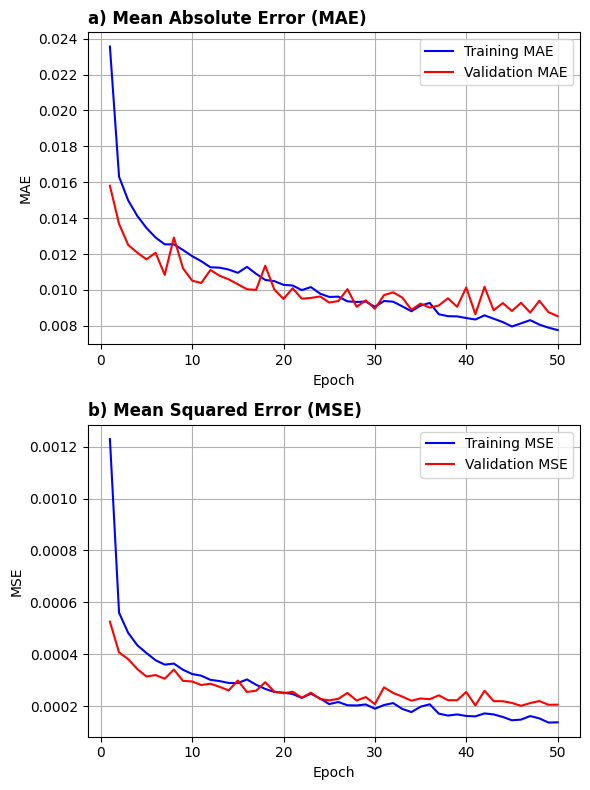

In [ ]:
# Evaluate the final model on the test set
print("\n📊 Evaluating Final Model on Test Data...")
test_loss, test_mae = final_birnn_model.evaluate(X_test_final_with_indices, y_test, verbose=0)

# Make predictions on the test set
y_pred_test = final_birnn_model.predict(X_test_final_with_indices)

# Calculate final test metrics
mse_test = mean_squared_error(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Display test metrics
print("\n🎯 Final Model Performance on Test Data:")
print(f"Test MSE: {mse_test:.4f}")
print(f"Test MAE: {mae_test:.4f}")
print(f"Test R² Score: {r2_test:.4f}")

# Save the final model
final_birnn_model.save('final_birnn_regression_model.h5')

# Plot training history
import matplotlib.pyplot as plt

def plot_training_validation_metrics(history):
    epochs = range(1, len(history.history['loss']) + 1)

    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_mse = history.history['loss']
    val_mse = history.history['val_loss']

    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    axes[0].plot(epochs, train_mae, label='Training MAE', color='blue')
    axes[0].plot(epochs, val_mae, label='Validation MAE', color='red')
    axes[0].set_title('a) Mean Absolute Error (MAE)', loc='left', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MAE')
    axes[0].legend()
    axes[0].grid()

    axes[1].plot(epochs, train_mse, label='Training MSE', color='blue')
    axes[1].plot(epochs, val_mse, label='Validation MSE', color='red')
    axes[1].set_title('b) Mean Squared Error (MSE)', loc='left', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MSE')
    axes[1].legend()
    axes[1].grid()

    plt.tight_layout()
    plt.show()

# Plot final model training history
plot_training_validation_metrics(history_final)

# Test BiRNN

In [ ]:
# Load unseen data
df_unseen = pd.read_csv(
    'large_fires_data_v2_predictions.csv',
    names= [
        'point_id',
        'lat_dd',
        'long_dd',
        'Aspect',
        'Climatic water deficit',
        'Elevation',
        'Humidity',
        'LULC',
        'NDVI',
        'Evaptranspiration',
        'Precipitation',
        'Slope',
        'Soil moisture',
        'Shortwave radiation flux',
        'Maximum Temperature',
        'Wind speed',
        'dist_fores',
        'human_foot',
        'tree_speci',
        'pdsi'
    ],
    header= 0
)

# Replace -9999 with NaN
df_unseen.replace(-9999, np.nan, inplace=True)

# Fill missing values using forward fill, then backward fill
df_unseen.fillna(method='ffill', inplace=True)
df_unseen.fillna(method='bfill', inplace=True)


replace_values_LULC = {
    1: 'Urban_areas',
    2: 'Crop_land',
    3: 'Grass_land',
    4: 'Tree_covered',
    5: 'Shrub_covered',
    6: 'Herbaceous',
    8: 'Sparse_vegetation',
    9: 'Bare_soil',
    10: 'Snow',
    11: 'Water_bodies',
}

df_unseen['LULC'] = df_unseen['LULC'].replace(replace_values_LULC)
# Convert necessary columns to categorical
df_unseen = df_unseen.astype(
    {
        'LULC': 'category'
    }
)

# Define categorical, numerical, and additional columns
categorical_columns = ['LULC']
numerical_columns = [
    'Climatic water deficit', 'Elevation', 'Humidity', 'NDVI',
    'Evaptranspiration', 'Precipitation', 'Slope', 'Soil moisture',
    'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed'
]
additional_columns = ['point_id', 'lat_dd', 'long_dd', 'dist_fores', 'human_foot', 'tree_speci', 'pdsi']  # Columns to retain

# Apply the trained encoder and scaler
X_unseen_encoded = pd.DataFrame(encoder.transform(df_unseen[categorical_columns]),
                                columns=encoder.get_feature_names_out(categorical_columns))
X_unseen_scaled = pd.DataFrame(scaler.transform(df_unseen[numerical_columns]), columns=numerical_columns)

# Concatenate encoded categorical and scaled numerical features
X_unseen_final = pd.concat([X_unseen_scaled.reset_index(drop=True), X_unseen_encoded.reset_index(drop=True)], axis=1)

# Save the processed unseen data to a CSV file
X_unseen_final.to_csv('unseen_data_preprocessed.csv', index=False)

# Display the first few rows of the processed data
X_unseen_final.head()


# Extract additional columns from the original unseen dataframe
X_unseen_additional = df_unseen[additional_columns].reset_index(drop=True)

# Concatenate processed numerical, encoded categorical, and additional columns
X_unseen_final = pd.concat([X_unseen_additional, X_unseen_scaled.reset_index(drop=True), X_unseen_encoded.reset_index(drop=True)], axis=1)

# Save the final processed unseen data to a CSV file
X_unseen_final.to_csv('unseen_data_preprocessed.csv', index=False)


# Define features to be removed
features_to_remove = [
    'Slope', 'LULC_Bare_soil', 'LULC_Grass_land', 'LULC_Herbaceous',
    'LULC_Shrub_covered', 'LULC_Snow', 'LULC_Sparse_vegetation',
    'LULC_Tree_covered', 'LULC_Urban_areas', 'LULC_Water_bodies']

# Drop the selected features from the unseen dataset
X_unseen_final_selected = X_unseen_final.drop(columns=features_to_remove, errors='ignore')

# Save the final feature-selected unseen dataset to a CSV file
X_unseen_final_selected.to_csv('unseen_data_preprocessed_selected.csv', index=False)

# Display the first few rows of the final dataset
X_unseen_final_selected.head()

<ipython-input-59-d0ed9f7ab97c>:33: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_unseen.fillna(method='ffill', inplace=True)
<ipython-input-59-d0ed9f7ab97c>:34: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_unseen.fillna(method='bfill', inplace=True)


,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,12493,48.383883,-123.961333,0.0,18.0,0.0,-1.644420,0.220652,-0.635412,3.571901,2.948433,-1.452216,5.118402,9.949277,0.573263,1.803726,-0.227430,0.0
1,12494,48.383883,-123.878000,0.0,18.0,0.0,-1.360750,0.488200,-0.635412,3.571901,2.948433,-1.290211,4.190799,9.109807,0.649534,1.954714,-0.272971,0.0
2,12495,48.383883,-123.794667,0.0,18.0,0.0,-1.257080,0.467257,-0.635412,3.571901,2.948433,-1.300138,4.052230,8.696123,0.623468,1.874057,-0.389329,0.0
3,12497,48.383883,-123.628000,0.0,18.0,30.0,-0.977667,0.830044,-0.635412,3.571901,3.504778,-1.167773,2.998933,7.524046,0.652037,1.918102,-0.375554,0.0
4,12498,48.383883,-123.544667,0.0,41.0,0.0,-0.797250,1.395641,-0.635412,3.556090,2.821264,-0.957905,1.722572,6.597038,0.698134,2.090593,-0.373367,0.0


In [ ]:
from tensorflow.keras.models import load_model
import tensorflow.keras.losses

# Load the trained BiRNN model
custom_objects = {
    "mse": tensorflow.keras.losses.MeanSquaredError()
}
final_birnn_model = load_model('final_birnn_regression_model.h5', custom_objects=custom_objects)

# Load the preprocessed unseen data
X_unseen_final_selected = pd.read_csv('unseen_data_preprocessed_selected.csv')

# Define features for prediction
features_for_prediction = [
    'Climatic water deficit', 'Elevation', 'Humidity',
    'NDVI', 'Evaptranspiration', 'Precipitation', 'Soil moisture',
    'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed',
]

# Extract only the required features
X_unseen_for_prediction = X_unseen_final_selected[features_for_prediction]

# Reshape for BiRNN (RNNs expect 3D input: (samples, timesteps, features))
X_unseen_for_prediction = X_unseen_for_prediction.values.reshape(
    (X_unseen_for_prediction.shape[0], X_unseen_for_prediction.shape[1], 1)
)

# Make predictions
predictions = final_birnn_model.predict(X_unseen_for_prediction)

# Rename the target feature and format to 4 decimal places
X_unseen_final_selected['wildfire_proba'] = predictions
X_unseen_final_selected['wildfire_proba'] = X_unseen_final_selected['wildfire_proba'].round(4)

# Keep only reference columns and the target feature
additional_features = ['point_id', 'lat_dd', 'long_dd', 'dist_fores', 'human_foot', 'tree_speci', 'pdsi']
final_unseen_results = X_unseen_final_selected[additional_features + ['wildfire_proba']]

# Save the results
final_unseen_results.to_csv('unseen_data_with_wildfire_proba_BiRNN.csv', index=False)

# Display first few rows of predictions
final_unseen_results.head()


5172/5172 ━━━━━━━━━━━━━━━━━━━━ 32s 6ms/step


,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,wildfire_proba
0,12493,48.383883,-123.961333,0.0,18.0,0.0,-1.644420,0.0521
1,12494,48.383883,-123.878000,0.0,18.0,0.0,-1.360750,0.0657
2,12495,48.383883,-123.794667,0.0,18.0,0.0,-1.257080,0.0591
3,12497,48.383883,-123.628000,0.0,18.0,30.0,-0.977667,0.0141
4,12498,48.383883,-123.544667,0.0,41.0,0.0,-0.797250,0.0299


# RNN model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define a function to create the RNN model
def create_rnn(input_shape, dropout_rate=0.1):
    model = Sequential([
        SimpleRNN(256, activation='relu', return_sequences=True, input_shape=(input_shape, 1)),
        Dropout(dropout_rate),
        SimpleRNN(128, activation='relu'),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')  # Output layer for regression
    ])
    return model

# Compile the model
def compile_rnn(model, learning_rate=0.001):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse',  # Mean Squared Error for regression
                  metrics=['mae'])  # Mean Absolute Error as an additional metric
    return model

# Store cross-validation results
cv_results = []

# Perform 10-Fold Spatial Cross-Validation
for fold_split in spatial_cv_splits:
    fold = fold_split["fold"]
    X_train_fold = fold_split["X_train"]
    y_train_fold = fold_split["y_train"]
    X_val_fold = fold_split["X_val"]
    y_val_fold = fold_split["y_val"]

    print(f"\n🔹 Training Fold {fold} (Train on 9 folds, Validate on 1 fold)...")

    # Reshape input data for RNN (RNNs expect 3D input: (samples, timesteps, features))
    X_train_fold = X_train_fold.values.reshape((X_train_fold.shape[0], X_train_fold.shape[1], 1))
    X_val_fold = X_val_fold.values.reshape((X_val_fold.shape[0], X_val_fold.shape[1], 1))

    # Define input shape
    input_shape = X_train_fold.shape[1]

    # Create and compile the RNN model
    rnn_model = create_rnn(input_shape)
    rnn_model = compile_rnn(rnn_model)

    # Train the model
    history = rnn_model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=100,
        batch_size=32,
        verbose=1
    )

    # Evaluate the model on the validation set
    val_loss, val_mae = rnn_model.evaluate(X_val_fold, y_val_fold, verbose=0)

    # Make predictions on the validation set
    y_pred_val = rnn_model.predict(X_val_fold)

    # Calculate regression metrics
    mse = mean_squared_error(y_val_fold, y_pred_val)
    mae = mean_absolute_error(y_val_fold, y_pred_val)
    r2 = r2_score(y_val_fold, y_pred_val)

    # Store results
    cv_results.append({
        "Fold": fold,
        "Validation MSE": mse,
        "Validation MAE": mae,
        "Validation R²": r2
    })

    print(f"✅ Fold {fold} Results: MSE={mse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")

# Convert results to DataFrame and display
cv_results_df = pd.DataFrame(cv_results)
print("\n📊 Cross-Validation Results:\n", cv_results_df)



🔹 Training Fold 0 (Train on 9 folds, Validate on 1 fold)...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 0.0016 - mae: 0.0274 - val_loss: 6.4627e-04 - val_mae: 0.0176
Epoch 2/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 5.9432e-04 - mae: 0.0164 - val_loss: 5.9148e-04 - val_mae: 0.0167
Epoch 3/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - loss: 4.7879e-04 - mae: 0.0146 - val_loss: 4.4811e-04 - val_mae: 0.0167
Epoch 4/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 4.4860e-04 - mae: 0.0138 - val_loss: 5.5372e-04 - val_mae: 0.0194
Epoch 5/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 4.0834e-04 - mae: 0.0127 - val_loss: 4.4470e-04 - val_mae: 0.0163
Epoch 6/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 3.5973e-04 - mae: 0.0123 - val_loss: 4.9904e-04 - val_mae: 0.0157
Epoch 7/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 3.4601e-04 - mae: 0.0117 - val_loss: 5.0425e-04 - val_mae: 0.0179
Epoch 8/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 3.1882e-04 - mae: 0.0114 - val_loss: 5.6230e

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


192/192 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0025 - mae: 0.0319 - val_loss: 0.0018 - val_mae: 0.0345
Epoch 2/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 5.9479e-04 - mae: 0.0166 - val_loss: 0.0016 - val_mae: 0.0351
Epoch 3/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 4.8184e-04 - mae: 0.0150 - val_loss: 0.0023 - val_mae: 0.0382
Epoch 4/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 4.4556e-04 - mae: 0.0141 - val_loss: 0.0017 - val_mae: 0.0321
Epoch 5/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 4.2337e-04 - mae: 0.0132 - val_loss: 0.0017 - val_mae: 0.0290
Epoch 6/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 4.0311e-04 - mae: 0.0129 - val_loss: 0.0022 - val_mae: 0.0328
Epoch 7/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 3.4056e-04 - mae: 0.0120 - val_loss: 0.0019 - val_mae: 0.0299
Epoch 8/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 3.2541e-04 - mae: 0.0116 - val_loss: 0.0027 - val_mae: 0.0349
Epoch 9/100
192/192 ━━━━

...

197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0014 - mae: 0.0259 - val_loss: 4.5304e-05 - val_mae: 0.0059
Epoch 2/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 5.9036e-04 - mae: 0.0166 - val_loss: 3.4871e-05 - val_mae: 0.0053
Epoch 3/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 4.7989e-04 - mae: 0.0149 - val_loss: 1.3949e-05 - val_mae: 0.0030
Epoch 4/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 4.8252e-04 - mae: 0.0145 - val_loss: 3.6622e-06 - val_mae: 0.0017
Epoch 5/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 4.2395e-04 - mae: 0.0136 - val_loss: 8.6550e-06 - val_mae: 0.0021
Epoch 6/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 3.6772e-04 - mae: 0.0129 - val_loss: 8.0826e-06 - val_mae: 0.0019
Epoch 7/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 4.0512e-04 - mae: 0.0133 - val_loss: 1.1570e-05 - val_mae: 0.0023
Epoch 8/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 3.5856e-04 - mae: 0.0124 - val_loss: 2.5584e-06 - val_mae:

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


191/191 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 0.0028 - mae: 0.0328 - val_loss: 7.4582e-04 - val_mae: 0.0174
Epoch 2/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 6.2456e-04 - mae: 0.0167 - val_loss: 6.3797e-04 - val_mae: 0.0162
Epoch 3/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 5.3283e-04 - mae: 0.0154 - val_loss: 5.2885e-04 - val_mae: 0.0150
Epoch 4/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 4.6008e-04 - mae: 0.0143 - val_loss: 5.4297e-04 - val_mae: 0.0157
Epoch 5/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 4.0970e-04 - mae: 0.0132 - val_loss: 6.8388e-04 - val_mae: 0.0171
Epoch 6/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 3.4592e-04 - mae: 0.0122 - val_loss: 6.5611e-04 - val_mae: 0.0184
Epoch 7/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 3.2735e-04 - mae: 0.0119 - val_loss: 7.5357e-04 - val_mae: 0.0184
Epoch 8/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 3.4310e-04 - mae: 0.0119 - val_loss: 5.6593e-04 - val_mae:

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


187/187 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - loss: 0.0014 - mae: 0.0245 - val_loss: 0.0015 - val_mae: 0.0248
Epoch 2/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 5.3489e-04 - mae: 0.0154 - val_loss: 0.0015 - val_mae: 0.0232
Epoch 3/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 3.9346e-04 - mae: 0.0132 - val_loss: 0.0013 - val_mae: 0.0209
Epoch 4/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - loss: 3.4776e-04 - mae: 0.0122 - val_loss: 0.0013 - val_mae: 0.0213
Epoch 5/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 3.3438e-04 - mae: 0.0118 - val_loss: 0.0013 - val_mae: 0.0218
Epoch 6/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 3.4403e-04 - mae: 0.0122 - val_loss: 0.0013 - val_mae: 0.0213
Epoch 7/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 2.9660e-04 - mae: 0.0113 - val_loss: 0.0014 - val_mae: 0.0226
Epoch 8/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 2.7591e-04 - mae: 0.0107 - val_loss: 0.0013 - val_mae: 0.0216
Epoch 9/100
187/187 ━━

In [ ]:
print("\n🚀 Training Final RNN Model on Full Training Data...")

# Load full training data
X_train_full = X_train_final_with_indices.drop(columns=["spatial_fold"])
y_train_full = y_train

# Reshape for RNN
X_train_full = X_train_full.values.reshape((X_train_full.shape[0], X_train_full.shape[1], 1))

# Define and compile the final RNN model
input_shape = X_train_full.shape[1]
final_rnn_model = create_rnn(input_shape)
final_rnn_model = compile_rnn(final_rnn_model)

history_final = final_rnn_model.fit(
    X_train_full, y_train_full,
    validation_data=(X_val_final_with_indices, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

# Save the trained model
final_rnn_model.save('final_rnn_regression_model.h5')



🚀 Training Final RNN Model on Full Training Data...
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


212/212 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 0.0017 - mae: 0.0279 - val_loss: 5.6841e-04 - val_mae: 0.0162
Epoch 2/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 6.1404e-04 - mae: 0.0168 - val_loss: 4.0792e-04 - val_mae: 0.0132
Epoch 3/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 4.8570e-04 - mae: 0.0147 - val_loss: 4.1409e-04 - val_mae: 0.0132
Epoch 4/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - loss: 3.9178e-04 - mae: 0.0134 - val_loss: 3.4810e-04 - val_mae: 0.0120
Epoch 5/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 3.9023e-04 - mae: 0.0129 - val_loss: 3.2532e-04 - val_mae: 0.0118
Epoch 6/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 3.4384e-04 - mae: 0.0123 - val_loss: 3.1831e-04 - val_mae: 0.0110
Epoch 7/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 3.5083e-04 - mae: 0.0120 - val_loss: 3.3221e-04 - val_mae: 0.0114
Epoch 8/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 3.0284e-04 - mae: 0.0114 - val_loss: 3.3001e-04 - val_ma

In [ ]:
print("\n📊 Evaluating Final Model on Test Data...")
test_loss, test_mae = final_rnn_model.evaluate(X_test_final_with_indices, y_test, verbose=0)

# Make predictions on the test set
y_pred_test = final_rnn_model.predict(X_test_final_with_indices)

# Calculate final test metrics
mse_test = mean_squared_error(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Display test metrics
print("\n🎯 Final Model Performance on Test Data:")
print(f"Test MSE: {mse_test:.4f}")
print(f"Test MAE: {mae_test:.4f}")
print(f"Test R² Score: {r2_test:.4f}")

# Save the final model
final_rnn_model.save('final_rnn_regression_model.h5')



📊 Evaluating Final Model on Test Data...
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step



🎯 Final Model Performance on Test Data:
Test MSE: 0.0003
Test MAE: 0.0092
Test R² Score: 0.7516


In [ ]:
from tensorflow.keras.models import load_model
import tensorflow.keras.losses

# Load the trained RNN model
custom_objects = {
    "mse": tensorflow.keras.losses.MeanSquaredError()
}
final_rnn_model = load_model('final_rnn_regression_model.h5', custom_objects=custom_objects)

# Load the preprocessed unseen data
X_unseen_final_selected = pd.read_csv('unseen_data_preprocessed_selected.csv')

# Define features for prediction
features_for_prediction = [
    'Climatic water deficit', 'Elevation', 'Humidity',
    'NDVI', 'Evaptranspiration', 'Precipitation', 'Soil moisture',
    'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed',
]

# Extract only the required features
X_unseen_for_prediction = X_unseen_final_selected[features_for_prediction]

# Reshape for RNN (RNNs expect 3D input: (samples, timesteps, features))
X_unseen_for_prediction = X_unseen_for_prediction.values.reshape(
    (X_unseen_for_prediction.shape[0], X_unseen_for_prediction.shape[1], 1)
)

# Make predictions
predictions = final_rnn_model.predict(X_unseen_for_prediction)

# Rename the target feature and format to 4 decimal places
X_unseen_final_selected['wildfire_proba'] = predictions
X_unseen_final_selected['wildfire_proba'] = X_unseen_final_selected['wildfire_proba'].round(4)

# Keep only reference columns and the target feature
additional_features = ['point_id', 'lat_dd', 'long_dd', 'dist_fores', 'human_foot', 'tree_speci', 'pdsi']
final_unseen_results = X_unseen_final_selected[additional_features + ['wildfire_proba']]

# Save the results
final_unseen_results.to_csv('unseen_data_with_wildfire_proba_RNN.csv', index=False)

# Display first few rows of predictions
print(final_unseen_results.head())


5172/5172 ━━━━━━━━━━━━━━━━━━━━ 44s 8ms/step
   point_id     lat_dd     long_dd  dist_fores  human_foot  tree_speci  \
0     12493  48.383883 -123.961333         0.0        18.0         0.0   
1     12494  48.383883 -123.878000         0.0        18.0         0.0   
2     12495  48.383883 -123.794667         0.0        18.0         0.0   
3     12497  48.383883 -123.628000         0.0        18.0        30.0   
4     12498  48.383883 -123.544667         0.0        41.0         0.0   

       pdsi  wildfire_proba  
0 -1.644420          0.0434  
1 -1.360750          0.0645  
2 -1.257080          0.0561  
3 -0.977667          0.0512  
4 -0.797250          0.0160  


# LSTM

## Train the LSTM model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define a function to create the LSTM model
def create_lstm(input_shape, dropout_rate=0.1):
    model = Sequential([
        LSTM(128, activation='relu', return_sequences=True, input_shape=(input_shape, 1)),
        Dropout(dropout_rate),
        LSTM(64, activation='relu'),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')  # Output layer for regression
    ])
    return model

# Compile the model
def compile_lstm(model, learning_rate=0.001):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse',  # Mean Squared Error for regression
                  metrics=['mae'])  # Mean Absolute Error as an additional metric
    return model

# Store cross-validation results
cv_results = []

# Perform 10-Fold Spatial Cross-Validation
for fold_split in spatial_cv_splits:
    fold = fold_split["fold"]
    X_train_fold = fold_split["X_train"]
    y_train_fold = fold_split["y_train"]
    X_val_fold = fold_split["X_val"]
    y_val_fold = fold_split["y_val"]

    print(f"\n🔹 Training Fold {fold} (Train on 9 folds, Validate on 1 fold)...")

    # Reshape input data for LSTM (LSTMs expect 3D input: (samples, timesteps, features))
    X_train_fold = X_train_fold.values.reshape((X_train_fold.shape[0], X_train_fold.shape[1], 1))
    X_val_fold = X_val_fold.values.reshape((X_val_fold.shape[0], X_val_fold.shape[1], 1))

    # Define input shape
    input_shape = X_train_fold.shape[1]

    # Create and compile the LSTM model
    lstm_model = create_lstm(input_shape)
    lstm_model = compile_lstm(lstm_model)

    # Train the model
    history = lstm_model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=50,
        batch_size=32,
        verbose=1
    )

    # Evaluate the model on the validation set
    val_loss, val_mae = lstm_model.evaluate(X_val_fold, y_val_fold, verbose=0)

    # Make predictions on the validation set
    y_pred_val = lstm_model.predict(X_val_fold)

    # Calculate regression metrics
    mse = mean_squared_error(y_val_fold, y_pred_val)
    mae = mean_absolute_error(y_val_fold, y_pred_val)
    r2 = r2_score(y_val_fold, y_pred_val)

    # Store results
    cv_results.append({
        "Fold": fold,
        "Validation MSE": mse,
        "Validation MAE": mae,
        "Validation R²": r2
    })

    print(f"✅ Fold {fold} Results: MSE={mse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")

# Convert results to DataFrame and display
cv_results_df = pd.DataFrame(cv_results)
print("\n📊 Cross-Validation Results:\n", cv_results_df)



🔹 Training Fold 0 (Train on 9 folds, Validate on 1 fold)...
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - loss: 0.0010 - mae: 0.0222 - val_loss: 4.6391e-04 - val_mae: 0.0152
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 6.8445e-04 - mae: 0.0170 - val_loss: 4.6063e-04 - val_mae: 0.0160
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 6.6130e-04 - mae: 0.0166 - val_loss: 5.6636e-04 - val_mae: 0.0162
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 5.9252e-04 - mae: 0.0154 - val_loss: 5.3963e-04 - val_mae: 0.0173
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - loss: 5.7083e-04 - mae: 0.0150 - val_loss: 5.6553e-04 - val_mae: 0.0180
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - loss: 5.2195e-04 - mae: 0.0146 - val_loss: 5.9616e-04 - val_mae: 0.0165
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 5.9190e-04 - mae: 0.0155 - val_loss: 5.6999e-04 - val_mae: 0.0165
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - loss: 5.1437e-04 - mae: 0.0142 - val_loss: 4.8800e-04 - val_mae: 0.01

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


192/192 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - loss: 0.0010 - mae: 0.0219 - val_loss: 4.1007e-04 - val_mae: 0.0155
Epoch 2/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - loss: 6.9972e-04 - mae: 0.0172 - val_loss: 8.1522e-04 - val_mae: 0.0244
Epoch 3/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 6.7690e-04 - mae: 0.0168 - val_loss: 6.1584e-04 - val_mae: 0.0198
Epoch 4/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - loss: 6.3867e-04 - mae: 0.0162 - val_loss: 4.5468e-04 - val_mae: 0.0178
Epoch 5/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 5.5732e-04 - mae: 0.0151 - val_loss: 4.5622e-04 - val_mae: 0.0176
Epoch 6/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 5.9799e-04 - mae: 0.0155 - val_loss: 4.6208e-04 - val_mae: 0.0171
Epoch 7/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 5.7007e-04 - mae: 0.0154 - val_loss: 4.0630e-04 - val_mae: 0.0156
Epoch 8/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 5.1328e-04 - mae: 0.0142 - val_loss: 3.3580e-04 - val_mae: 0.014

...

197/197 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 9.6882e-04 - mae: 0.0218 - val_loss: 3.5778e-05 - val_mae: 0.0052
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 7.2506e-04 - mae: 0.0185 - val_loss: 1.0507e-05 - val_mae: 0.0028
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 6.8027e-04 - mae: 0.0177 - val_loss: 7.0818e-05 - val_mae: 0.0083
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 6.1889e-04 - mae: 0.0168 - val_loss: 9.3013e-06 - val_mae: 0.0025
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - loss: 6.5659e-04 - mae: 0.0173 - val_loss: 5.9221e-06 - val_mae: 0.0020
Epoch 6/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 5.6762e-04 - mae: 0.0161 - val_loss: 5.0404e-05 - val_mae: 0.0067
Epoch 7/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 5.8811e-04 - mae: 0.0161 - val_loss: 5.2987e-05 - val_mae: 0.0069
Epoch 8/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 5.6721e-04 - mae: 0.0156 - val_loss: 6.7031e-05 - val_mae: 

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


191/191 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 0.0010 - mae: 0.0217 - val_loss: 6.1921e-04 - val_mae: 0.0184
Epoch 2/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 7.2075e-04 - mae: 0.0182 - val_loss: 6.0186e-04 - val_mae: 0.0165
Epoch 3/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - loss: 6.5734e-04 - mae: 0.0166 - val_loss: 6.0775e-04 - val_mae: 0.0155
Epoch 4/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 5.9198e-04 - mae: 0.0158 - val_loss: 6.1945e-04 - val_mae: 0.0180
Epoch 5/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 5.7524e-04 - mae: 0.0155 - val_loss: 6.0323e-04 - val_mae: 0.0161
Epoch 6/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 5.2731e-04 - mae: 0.0150 - val_loss: 5.6592e-04 - val_mae: 0.0156
Epoch 7/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 5.3799e-04 - mae: 0.0147 - val_loss: 5.8507e-04 - val_mae: 0.0165
Epoch 8/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 5.2980e-04 - mae: 0.0149 - val_loss: 6.1740e-04 - val_mae: 0.01

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


187/187 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - loss: 8.4578e-04 - mae: 0.0201 - val_loss: 0.0016 - val_mae: 0.0263
Epoch 2/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - loss: 5.6593e-04 - mae: 0.0156 - val_loss: 0.0015 - val_mae: 0.0257
Epoch 3/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 6.0279e-04 - mae: 0.0162 - val_loss: 0.0018 - val_mae: 0.0268
Epoch 4/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - loss: 4.8368e-04 - mae: 0.0144 - val_loss: 0.0019 - val_mae: 0.0273
Epoch 5/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 4.7025e-04 - mae: 0.0141 - val_loss: 0.0018 - val_mae: 0.0264
Epoch 6/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 4.5571e-04 - mae: 0.0138 - val_loss: 0.0015 - val_mae: 0.0237
Epoch 7/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 5.1488e-04 - mae: 0.0144 - val_loss: 0.0017 - val_mae: 0.0253
Epoch 8/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - loss: 4.2301e-04 - mae: 0.0136 - val_loss: 0.0014 - val_mae: 0.0232
Epoch 9/50
187/187 ━━━━━

## Train the final LSTM model

In [ ]:
print("\n🚀 Training Final LSTM Model on Full Training Data...")

# Load full training data
X_train_full = X_train_final_with_indices.drop(columns=["spatial_fold"])
y_train_full = y_train

# Reshape for LSTM
X_train_full = X_train_full.values.reshape((X_train_full.shape[0], X_train_full.shape[1], 1))

# Define and compile the final LSTM model
input_shape = X_train_full.shape[1]
final_lstm_model = create_lstm(input_shape)
final_lstm_model = compile_lstm(final_lstm_model)

history_final = final_lstm_model.fit(
    X_train_full, y_train_full,
    validation_data=(X_val_final_with_indices, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

# Save the trained model
final_lstm_model.save('final_lstm_regression_model.h5')



🚀 Training Final LSTM Model on Full Training Data...
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


212/212 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - loss: 8.7575e-04 - mae: 0.0202 - val_loss: 6.2463e-04 - val_mae: 0.0189
Epoch 2/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 6.8935e-04 - mae: 0.0177 - val_loss: 5.3361e-04 - val_mae: 0.0158
Epoch 3/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 6.1596e-04 - mae: 0.0164 - val_loss: 5.1350e-04 - val_mae: 0.0136
Epoch 4/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 5.7095e-04 - mae: 0.0157 - val_loss: 4.8761e-04 - val_mae: 0.0151
Epoch 5/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 4.9702e-04 - mae: 0.0148 - val_loss: 4.3741e-04 - val_mae: 0.0135
Epoch 6/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 5.1601e-04 - mae: 0.0150 - val_loss: 4.5896e-04 - val_mae: 0.0128
Epoch 7/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 5.0675e-04 - mae: 0.0144 - val_loss: 4.7107e-04 - val_mae: 0.0134
Epoch 8/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 5.5028e-04 - mae: 0.0150 - val_loss: 4.2407e-04 - val_mae: 

## Evaluate the Final model on the test set

In [ ]:
print("\n📊 Evaluating Final Model on Test Data...")
test_loss, test_mae = final_lstm_model.evaluate(X_test_final_with_indices, y_test, verbose=0)

# Make predictions on the test set
y_pred_test = final_lstm_model.predict(X_test_final_with_indices)

# Calculate final test metrics
mse_test = mean_squared_error(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Display test metrics
print("\n🎯 Final Model Performance on Test Data:")
print(f"Test MSE: {mse_test:.4f}")
print(f"Test MAE: {mae_test:.4f}")
print(f"Test R² Score: {r2_test:.4f}")

# Save the final model
final_lstm_model.save('final_lstm_regression_model.h5')



📊 Evaluating Final Model on Test Data...
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step



🎯 Final Model Performance on Test Data:
Test MSE: 0.0003
Test MAE: 0.0108
Test R² Score: 0.7122


## Predict Wildfire Probability on unseen data

In [ ]:
from tensorflow.keras.models import load_model
import tensorflow.keras.losses

# Load the trained LSTM model
custom_objects = {
    "mse": tensorflow.keras.losses.MeanSquaredError()
}
final_lstm_model = load_model('final_lstm_regression_model.h5', custom_objects=custom_objects)

# Load the preprocessed unseen data
X_unseen_final_selected = pd.read_csv('unseen_data_preprocessed_selected.csv')

# Define features for prediction
features_for_prediction = [
    'Climatic water deficit', 'Elevation', 'Humidity',
    'NDVI', 'Evaptranspiration', 'Precipitation', 'Soil moisture',
    'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed'
]

# Extract only the required features
X_unseen_for_prediction = X_unseen_final_selected[features_for_prediction]

# Reshape for LSTM (LSTMs expect 3D input: (samples, timesteps, features))
X_unseen_for_prediction = X_unseen_for_prediction.values.reshape(
    (X_unseen_for_prediction.shape[0], X_unseen_for_prediction.shape[1], 1)
)

# Make predictions
predictions = final_lstm_model.predict(X_unseen_for_prediction)

# Rename the target feature and format to 4 decimal places
X_unseen_final_selected['wildfire_proba'] = predictions
X_unseen_final_selected['wildfire_proba'] = X_unseen_final_selected['wildfire_proba'].round(4)

# Keep only reference columns and the target feature
additional_features = ['point_id', 'lat_dd', 'long_dd', 'dist_fores', 'human_foot', 'tree_speci', 'pdsi']
final_unseen_results = X_unseen_final_selected[additional_features + ['wildfire_proba']]

# Save the results
final_unseen_results.to_csv('unseen_data_with_wildfire_proba_LSTM.csv', index=False)

# Display first few rows of predictions
final_unseen_results.head()

5172/5172 ━━━━━━━━━━━━━━━━━━━━ 40s 8ms/step


,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,wildfire_proba
0,12493,48.383883,-123.961333,0.0,18.0,0.0,-1.644420,0.0058
1,12494,48.383883,-123.878000,0.0,18.0,0.0,-1.360750,0.0145
2,12495,48.383883,-123.794667,0.0,18.0,0.0,-1.257080,0.0139
3,12497,48.383883,-123.628000,0.0,18.0,30.0,-0.977667,0.0099
4,12498,48.383883,-123.544667,0.0,41.0,0.0,-0.797250,0.0151


# Encoder-Decoder BiRNN

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Bidirectional, SimpleRNN, RepeatVector, TimeDistributed
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define a function to create the Encoder-Decoder BiRNN model
def create_encoder_decoder_birnn(input_shape, dropout_rate=0.1):
    # Encoder
    encoder_inputs = Input(shape=(input_shape, 1))
    encoder = Bidirectional(SimpleRNN(128, activation='relu', return_sequences=False))(encoder_inputs)
    encoder = Dropout(dropout_rate)(encoder)

    # Repeat the context vector to match output shape
    decoder_inputs = RepeatVector(1)(encoder)  # 1 means we predict one target value

    # Decoder
    decoder = Bidirectional(SimpleRNN(64, activation='relu', return_sequences=True))(decoder_inputs)
    decoder = Dropout(dropout_rate)(decoder)

    # Final output layer
    outputs = TimeDistributed(Dense(1, activation='linear'))(decoder)

    # Define model
    model = Model(inputs=encoder_inputs, outputs=outputs)

    return model

# Compile the model
def compile_encoder_decoder_birnn(model, learning_rate=0.001):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse',  # Mean Squared Error for regression
                  metrics=['mae'])  # Mean Absolute Error as an additional metric
    return model

# Store cross-validation results
cv_results = []

# Perform 10-Fold Spatial Cross-Validation
for fold_split in spatial_cv_splits:
    fold = fold_split["fold"]
    X_train_fold = fold_split["X_train"]
    y_train_fold = fold_split["y_train"]
    X_val_fold = fold_split["X_val"]
    y_val_fold = fold_split["y_val"]

    print(f"\n🔹 Training Fold {fold} (Train on 9 folds, Validate on 1 fold)...")

    # Reshape input data for Encoder-Decoder BiRNN (RNNs expect 3D input: (samples, timesteps, features))
    X_train_fold = X_train_fold.values.reshape((X_train_fold.shape[0], X_train_fold.shape[1], 1))
    X_val_fold = X_val_fold.values.reshape((X_val_fold.shape[0], X_val_fold.shape[1], 1))
    y_train_fold = y_train_fold.values.reshape((y_train_fold.shape[0], 1, 1))  # Target also needs to be reshaped
    y_val_fold = y_val_fold.values.reshape((y_val_fold.shape[0], 1, 1))

    # Define input shape
    input_shape = X_train_fold.shape[1]

    # Create and compile the Encoder-Decoder BiRNN model
    birnn_encoder_decoder_model = create_encoder_decoder_birnn(input_shape)
    birnn_encoder_decoder_model = compile_encoder_decoder_birnn(birnn_encoder_decoder_model)

    # Train the model
    history = birnn_encoder_decoder_model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=50,
        batch_size=32,
        verbose=1
    )

    # Evaluate the model on the validation set
    val_loss, val_mae = birnn_encoder_decoder_model.evaluate(X_val_fold, y_val_fold, verbose=0)

    # Make predictions on the validation set
    y_pred_val = birnn_encoder_decoder_model.predict(X_val_fold).reshape(-1)

    # Calculate regression metrics
    mse = mean_squared_error(y_val_fold.reshape(-1), y_pred_val)
    mae = mean_absolute_error(y_val_fold.reshape(-1), y_pred_val)
    r2 = r2_score(y_val_fold.reshape(-1), y_pred_val)

    # Store results
    cv_results.append({
        "Fold": fold,
        "Validation MSE": mse,
        "Validation MAE": mae,
        "Validation R²": r2
    })

    print(f"✅ Fold {fold} Results: MSE={mse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")

# Convert results to DataFrame and display
cv_results_df = pd.DataFrame(cv_results)
print("\n📊 Cross-Validation Results:\n", cv_results_df)



🔹 Training Fold 0 (Train on 9 folds, Validate on 1 fold)...
Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.0031 - mae: 0.0372 - val_loss: 8.9523e-04 - val_mae: 0.0237
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 6.3009e-04 - mae: 0.0176 - val_loss: 4.4615e-04 - val_mae: 0.0163
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 4.9371e-04 - mae: 0.0146 - val_loss: 5.2562e-04 - val_mae: 0.0179
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 4.4106e-04 - mae: 0.0141 - val_loss: 4.8831e-04 - val_mae: 0.0163
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 3.6009e-04 - mae: 0.0127 - val_loss: 4.0881e-04 - val_mae: 0.0151
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 3.9545e-04 - mae: 0.0130 - val_loss: 3.9336e-04 - val_mae: 0.0149
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 3.5166e-04 - mae: 0.0123 - val_loss: 5.1837e-04 - val_mae: 0.0178
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step -

In [ ]:
print("\n🚀 Training Final Encoder-Decoder BiRNN Model on Full Training Data...")

# Load full training data
X_train_full = X_train_final_with_indices.drop(columns=["spatial_fold"])
y_train_full = y_train

# Reshape for Encoder-Decoder BiRNN
X_train_full = X_train_full.values.reshape((X_train_full.shape[0], X_train_full.shape[1], 1))
y_train_full = y_train_full.values.reshape((y_train_full.shape[0], 1, 1))  # Target also needs reshaping

# Define and compile the final model
input_shape = X_train_full.shape[1]
final_birnn_encoder_decoder_model = create_encoder_decoder_birnn(input_shape)
final_birnn_encoder_decoder_model = compile_encoder_decoder_birnn(final_birnn_encoder_decoder_model)

history_final = final_birnn_encoder_decoder_model.fit(
    X_train_full, y_train_full,
    validation_data=(X_val_final_with_indices.values.reshape((X_val_final_with_indices.shape[0], X_val_final_with_indices.shape[1], 1)),
                     y_val.values.reshape((y_val.shape[0], 1, 1))),
    epochs=50,
    batch_size=32,
    verbose=1
)

# Save the trained model
final_birnn_encoder_decoder_model.save('final_encoder_decoder_birnn_model.h5')



🚀 Training Final Encoder-Decoder BiRNN Model on Full Training Data...
Epoch 1/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 0.0029 - mae: 0.0373 - val_loss: 4.7855e-04 - val_mae: 0.0155
Epoch 2/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5.8664e-04 - mae: 0.0170 - val_loss: 4.3865e-04 - val_mae: 0.0137
Epoch 3/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.6999e-04 - mae: 0.0149 - val_loss: 3.5111e-04 - val_mae: 0.0120
Epoch 4/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 3.9008e-04 - mae: 0.0134 - val_loss: 3.7787e-04 - val_mae: 0.0123
Epoch 5/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 3.8921e-04 - mae: 0.0132 - val_loss: 3.1333e-04 - val_mae: 0.0116
Epoch 6/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 3.6436e-04 - mae: 0.0126 - val_loss: 3.4884e-04 - val_mae: 0.0119
Epoch 7/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.5237e-04 - mae: 0.0123 - val_loss: 3.1876e-04 - val_mae: 0.0115
Epoch 8/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 1

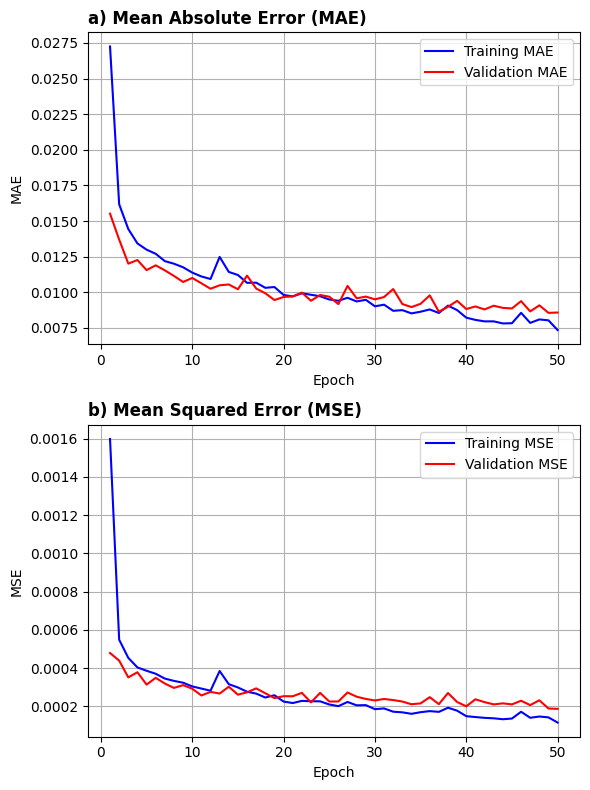

In [ ]:
import matplotlib.pyplot as plt

def plot_training_validation_metrics(history):
    epochs = range(1, len(history.history['loss']) + 1)

    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_mse = history.history['loss']
    val_mse = history.history['val_loss']

    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    # Plot MAE
    axes[0].plot(epochs, train_mae, label='Training MAE', color='blue')
    axes[0].plot(epochs, val_mae, label='Validation MAE', color='red')
    axes[0].set_title('a) Mean Absolute Error (MAE)', loc='left', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MAE')
    axes[0].legend()
    axes[0].grid()

    # Plot MSE
    axes[1].plot(epochs, train_mse, label='Training MSE', color='blue')
    axes[1].plot(epochs, val_mse, label='Validation MSE', color='red')
    axes[1].set_title('b) Mean Squared Error (MSE)', loc='left', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MSE')
    axes[1].legend()
    axes[1].grid()

    plt.tight_layout()
    plt.show()

# Call the function to plot training and validation metrics
plot_training_validation_metrics(history_final)


In [ ]:
from tensorflow.keras.models import load_model
import tensorflow.keras.losses
import pandas as pd

# Load the trained Encoder-Decoder BiRNN model
custom_objects = {
    "mse": tensorflow.keras.losses.MeanSquaredError()
}
final_birnn_encoder_decoder_model = load_model('final_encoder_decoder_birnn_model.h5', custom_objects=custom_objects)

# Load the preprocessed unseen data
X_unseen_final_selected = pd.read_csv('unseen_data_preprocessed_selected.csv')



In [ ]:
X_unseen_final_selected.head()

,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed
0,12493,48.383883,-123.961333,0.0,18.0,0.0,-1.644420,0.220652,-0.635412,3.571901,2.948433,-1.452216,5.118402,9.949277,0.573263,1.803726,-0.227430
1,12494,48.383883,-123.878000,0.0,18.0,0.0,-1.360750,0.488200,-0.635412,3.571901,2.948433,-1.290211,4.190799,9.109807,0.649534,1.954714,-0.272971
2,12495,48.383883,-123.794667,0.0,18.0,0.0,-1.257080,0.467257,-0.635412,3.571901,2.948433,-1.300138,4.052230,8.696123,0.623468,1.874057,-0.389329
3,12497,48.383883,-123.628000,0.0,18.0,30.0,-0.977667,0.830044,-0.635412,3.571901,3.504778,-1.167773,2.998933,7.524046,0.652037,1.918102,-0.375554
4,12498,48.383883,-123.544667,0.0,41.0,0.0,-0.797250,1.395641,-0.635412,3.556090,2.821264,-0.957905,1.722572,6.597038,0.698134,2.090593,-0.373367


In [ ]:
# Define features for prediction (Check if any feature is missing)
features_for_prediction = [
    'Climatic water deficit', 'Elevation', 'Humidity',
    'NDVI', 'Evaptranspiration', 'Precipitation', 'Soil moisture',
    'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed'
]

# Verify the number of features required by the model
expected_feature_count = 11  # From the error message
actual_feature_count = len(features_for_prediction)

if actual_feature_count < expected_feature_count:
    print(f"Warning: Model expects {expected_feature_count} features, but only {actual_feature_count} are provided.")

# Extract only the required features
X_unseen_for_prediction = X_unseen_final_selected[features_for_prediction]

# Print shape before reshaping
print("Original shape:", X_unseen_for_prediction.shape)

# Ensure the shape matches the expected input (samples, timesteps, features)
# If timesteps are expected to be 11, add a placeholder feature
if X_unseen_for_prediction.shape[1] < expected_feature_count:
    missing_features = expected_feature_count - X_unseen_for_prediction.shape[1]
    for i in range(missing_features):
        X_unseen_for_prediction[f'missing_feature_{i+1}'] = 0  # Adding dummy values

# Reshape for Encoder-Decoder BiRNN (3D input: (samples, timesteps, features))
X_unseen_for_prediction = X_unseen_for_prediction.values.reshape(
    (X_unseen_for_prediction.shape[0], expected_feature_count, 1)
)

# Print shape after reshaping
print("Reshaped shape:", X_unseen_for_prediction.shape)

# Make predictions
predictions = final_birnn_encoder_decoder_model.predict(X_unseen_for_prediction).reshape(-1)

# Rename the target feature and format to 4 decimal places
X_unseen_final_selected['wildfire_proba'] = predictions
X_unseen_final_selected['wildfire_proba'] = X_unseen_final_selected['wildfire_proba'].round(4)

# Keep only reference columns and the target feature
additional_features = ['point_id', 'lat_dd', 'long_dd', 'dist_fores', 'human_foot', 'tree_speci', 'pdsi']
final_unseen_results = X_unseen_final_selected[additional_features + ['wildfire_proba']]

# Save the results to a CSV file
final_unseen_results.to_csv('unseen_data_with_wildfire_proba_EncoderDecoderBiRNN.csv', index=False)

# Display first few rows of predictions
print(final_unseen_results.head())


Original shape: (165498, 10)
Reshaped shape: (165498, 11, 1)


<ipython-input-105-f76de2365cdf>:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_unseen_for_prediction[f'missing_feature_{i+1}'] = 0  # Adding dummy values


5172/5172 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step
   point_id     lat_dd     long_dd  dist_fores  human_foot  tree_speci  \
0     12493  48.383883 -123.961333         0.0        18.0         0.0   
1     12494  48.383883 -123.878000         0.0        18.0         0.0   
2     12495  48.383883 -123.794667         0.0        18.0         0.0   
3     12497  48.383883 -123.628000         0.0        18.0        30.0   
4     12498  48.383883 -123.544667         0.0        41.0         0.0   

       pdsi  wildfire_proba  
0 -1.644420          0.0117  
1 -1.360750          0.0072  
2 -1.257080          0.0073  
3 -0.977667          0.0088  
4 -0.797250          0.0111  


# CatBoost

## Step 1: Train the CatBoost on Spatial CV

In [ ]:
! pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 6.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Store cross-validation results
cv_results = []

# Perform 10-Fold Spatial Cross-Validation
for fold_split in spatial_cv_splits:
    fold = fold_split["fold"]
    X_train_fold = fold_split["X_train"]
    y_train_fold = fold_split["y_train"]
    X_val_fold = fold_split["X_val"]
    y_val_fold = fold_split["y_val"]

    print(f"\n🔹 Training Fold {fold} (Train on 9 folds, Validate on 1 fold)...")

    # Define CatBoost Model
    catboost_model = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.05,
        depth=8,
        loss_function='RMSE',
        random_seed=42,
        verbose=200
    )

    # Train model
    catboost_model.fit(X_train_fold, y_train_fold, eval_set=(X_val_fold, y_val_fold), early_stopping_rounds=100)

    # Make predictions on the validation set
    y_pred_val = catboost_model.predict(X_val_fold)

    # Calculate regression metrics
    mse = mean_squared_error(y_val_fold, y_pred_val)
    mae = mean_absolute_error(y_val_fold, y_pred_val)
    r2 = r2_score(y_val_fold, y_pred_val)

    # Store results
    cv_results.append({
        "Fold": fold,
        "Validation MSE": mse,
        "Validation MAE": mae,
        "Validation R²": r2
    })

    print(f"✅ Fold {fold} Results: MSE={mse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")

# Convert results to DataFrame and display
cv_results_df = pd.DataFrame(cv_results)
print("\n📊 Cross-Validation Results:\n", cv_results_df)



🔹 Training Fold 0 (Train on 9 folds, Validate on 1 fold)...
0:	learn: 0.0330614	test: 0.0219494	best: 0.0219494 (0)	total: 59.5ms	remaining: 59.4s
200:	learn: 0.0132876	test: 0.0184119	best: 0.0183115 (185)	total: 2.7s	remaining: 10.7s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.01831151268
bestIteration = 185

Shrink model to first 186 iterations.
✅ Fold 0 Results: MSE=0.0003, MAE=0.0142, R²=0.3223

🔹 Training Fold 1 (Train on 9 folds, Validate on 1 fold)...
0:	learn: 0.0330549	test: 0.0197572	best: 0.0197572 (0)	total: 27ms	remaining: 27s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.01975723631
bestIteration = 0

Shrink model to first 1 iterations.
✅ Fold 1 Results: MSE=0.0004, MAE=0.0169, R²=-0.3616

🔹 Training Fold 2 (Train on 9 folds, Validate on 1 fold)...
0:	learn: 0.0315123	test: 0.0370877	best: 0.0370877 (0)	total: 36.2ms	remaining: 36.1s
200:	learn: 0.0132191	test: 0.0222812	best: 0.0222609 (192)	total: 6.45s	remaining: 25.7s


## Step 2: Train Final CatBoost Model on Full Training Data

In [ ]:
print("\n🚀 Training Final CatBoost Model on Full Training Data...")

# Load full training data
X_train_full = X_train_final_with_indices.drop(columns=["spatial_fold"])
y_train_full = y_train

# Define and train the final CatBoost model
final_catboost_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function='RMSE',
    random_seed=42,
    verbose=200
)

final_catboost_model.fit(X_train_full, y_train_full)

# Save the trained model
final_catboost_model.save_model('final_catboost_regression_model.cbm')



🚀 Training Final CatBoost Model on Full Training Data...
0:	learn: 0.0321431	total: 9.22ms	remaining: 9.21s
200:	learn: 0.0135735	total: 3.96s	remaining: 15.7s
400:	learn: 0.0104984	total: 8.63s	remaining: 12.9s
600:	learn: 0.0086183	total: 13.4s	remaining: 8.92s
800:	learn: 0.0074098	total: 19.3s	remaining: 4.8s
999:	learn: 0.0064555	total: 24.7s	remaining: 0us


## Step 3: Predict Wildfire Probability on Unseen Data

In [ ]:
# Load preprocessed unseen data
X_unseen_final_selected = pd.read_csv('unseen_data_preprocessed_selected.csv')

# Define features for prediction
features_for_prediction = [
    'Climatic water deficit', 'Elevation', 'Humidity',
    'NDVI', 'Evaptranspiration', 'Precipitation', 'Soil moisture',
    'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed', 'LULC_Crop_land'
]

# Extract only the required features
X_unseen_for_prediction = X_unseen_final_selected[features_for_prediction]

# Load the trained CatBoost model
final_catboost_model = CatBoostRegressor()
final_catboost_model.load_model('final_catboost_regression_model.cbm')

# Make predictions
predictions = final_catboost_model.predict(X_unseen_for_prediction)

# Rename the target feature and format to 4 decimal places
X_unseen_final_selected['wildfire_proba'] = predictions.round(4)

# Keep only reference columns and the target feature
additional_features = ['point_id', 'lat_dd', 'long_dd', 'dist_fores', 'human_foot', 'tree_speci', 'pdsi']
final_unseen_results = X_unseen_final_selected[additional_features + ['wildfire_proba']]

# Save the results to a CSV file
final_unseen_results.to_csv('unseen_data_with_wildfire_proba_CatBoost.csv', index=False)

# Display first few rows of predictions
print(final_unseen_results.head())


   point_id     lat_dd     long_dd  dist_fores  human_foot  tree_speci  \
0     12493  48.383883 -123.961333         0.0        18.0         0.0   
1     12494  48.383883 -123.878000         0.0        18.0         0.0   
2     12495  48.383883 -123.794667         0.0        18.0         0.0   
3     12497  48.383883 -123.628000         0.0        18.0        30.0   
4     12498  48.383883 -123.544667         0.0        41.0         0.0   

       pdsi  wildfire_proba  
0 -1.644420          0.0066  
1 -1.360750          0.0185  
2 -1.257080          0.0129  
3 -0.977667          0.0236  
4 -0.797250          0.0344  
